In [80]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from scipy import stats
import itertools
import seaborn as sns
# import seaborn_image as isns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.special import logit
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib
# import scienceplots
# from matplotlib import rc
# rc("text", usetex=False)
# plt.style.use(['science', 'nature'])
%matplotlib inline

In [81]:
# Set visualisation parameters
sns.set_context("notebook", rc={"font.family": 'sans-serif',
                                'font.sans-serif': 'Helvetica'})
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.tight_layout()
sns.set(font_scale=2) 
sns.set_style("ticks")

<Figure size 640x480 with 0 Axes>

# Visualisation Functions

In [82]:
def category_plotting(x, y, hue, data, order = []):
    fig,ax = plt.subplots()
    sns.boxplot(x = x,
                y = y,
                hue = hue,
                data = data,
                order = order, palette = ['Tab:red'],
               boxprops=dict(alpha=.5), showcaps=False,showfliers = False, linewidth=1.7)


    sns.swarmplot(x = x,
                  y = y,
                  hue = hue,
                  data = data,
                  order = order,
                  dodge = True, palette = ['Tab:red'],marker='o', size=3, linewidth=1,zorder=1, edgecolor='gray')
    
    

    handles, labels = ax.get_legend_handles_labels()
    lgd = ax.legend(handles[0:2], labels[0:2],
                   bbox_to_anchor=(1.05, 1), 
                   loc=2, borderaxespad=0,
                   fontsize='large',
                   handletextpad = 0.5)
    sns.despine()
                   

    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .5))
        
    return ax

def category_plotting_2(x, y, hue, data, ax, palette):
    sns.swarmplot(x = x,
                y = y, 
                hue = hue,
                data = data,
                dodge = True, 
                ax = ax, palette = palette)
    
    sns.barplot(x = x,
                y = y, 
                hue = hue,
                data = data,
                alpha = 0.7,
                ax = ax, palette = palette)
    
    sns.despine()
    handles, labels = ax.get_legend_handles_labels()
    # lgd = ax.legend(handles[0:2], labels[0:2],
    #                bbox_to_anchor=(1.05, 1), fontsize = 'medium', 
    #                loc=2, borderaxespad=0,
    #                handletextpad = 0.5)
    lgd = ax.legend(handles[0:2], [],
                   bbox_to_anchor=(1.05, 1), fontsize = 'medium', 
                   loc=2, borderaxespad=0,
                   handletextpad = 0.5)
    

def paired_line(data, lines, column1, cond1_ls, column2, cond2, x_axis, colour = 'ro-'):
    plt.rcParams["figure.figsize"] = (3,10)
    for i in range(len(lines)):
        line_data = data[data[column1] == cond1_ls[i]]
        if line_data[column2].item() == cond2:
            plt.plot(x_axis, lines[i], colour , alpha = 0.8) 
        else:
            plt.plot(x_axis, lines[i], 'ko-', alpha = 0.3)
    sns.despine()
    
def autolabel(g, list):
    i = 0
    for ax in g.axes.ravel():
        for p in ax.patches:
            ax.annotate('n =' + str(list[i]), (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center', fontsize=13, color='black', xytext=(0, 8),
            textcoords='offset points')
            i = i + 1

def autolabel_2(ax, list):
    i = 0
    for p in ax.patches:
        ax.annotate('n = '+ str(list[i]), (p.get_x() + p.get_width() / 2., 0), 
                    ha='center', va='center', xytext=(0, 12), 
                    textcoords='offset points', fontsize = 14)
        i = i+1

# Statistics Functions

## Permutation and bootstrap tool

In [83]:
def itertool_stats(dict, method, key = None, ns = None):
    for subset in itertools.combinations(dict.keys(), 2):
        if method == 'chi2_contingency':
            stat, p, dof, expected  = stats.chi2_contingency([[dict[subset[0]], ns[subset[0]] - dict[subset[0]]],
                                                [dict[subset[1]], ns[subset[1]] - dict[subset[1]]]])
            print(subset, p)
        elif method == 'fisher':
            oddsratio, p  = stats.fisher_exact([dict[subset[0]],
                                        dict[subset[1]]])
            print(subset, p)
        elif method == 'ttest':
            stat, p = stats.ttest_ind(dict[subset[0]],
                                       dict[subset[1]],
                                       equal_var = False)
            print(subset, p)
            
def bootstrap(data, n = 5, func=np.mean):
    """
    Generate `n` bootstrap samples, evaluating `func`
    at each resampling. `bootstrap` returns a function,
    which can be called to obtain confidence intervals
    of interest.
    """
    simulations = list()
    sample_size = len(data)
    xbar_init = np.mean(data)
    for c in range(n):
        itersample = np.random.choice(data, size=sample_size, replace = True)
        simulations.append(func(itersample))
    return(simulations)


def compute_conditional(data, con1, con1_parameter,con2,con2_parameter ):
    agg_data = data[data[con1_parameter] == con1]
    parental_data = data[data[con2_parameter] == con2]
    union_data = agg_data[agg_data[con2_parameter] == con2]
    n = len(parental_data)
    if len(agg_data) == 0:
        return 0
    elif len(parental_data) == 0:
        return 0
    else:  
        p = len(union_data) / len(parental_data)
        return p, n

# Data extraction and condition definition

In [93]:
data = pd.read_csv('negative_parental_switch_summary.csv', encoding='cp1252')
exp_conds = data['exp_cond'].unique()
#estrous_stages = data['estrous_stage'].unique()
estrous_stages = ['P', 'E', 'M', 'D']
agg_conds = ['all_stressor_5h', 'food_deprivation']

# Deprivation time

In [338]:
# set up dataframe
df = pd.read_csv('deprivation_time.csv')
df = df[df['valid']!='invalid']
count = df.groupby(['deprivation_duration']).size().reset_index(name = 'count')
n = df.groupby(['deprivation_duration','state_after']).size().reset_index(name = 'n')
dep = count.merge(n, how = 'outer', on = 'deprivation_duration')
dep['percent'] = dep['n'] /dep['count']
dep = dep[dep.state_after == 'Agg+']
dep = pd.concat([dep, pd.DataFrame({'deprivation_duration': 0, 'count':21, 'state_after': 'Agg+','n':0,  'percent':0}, index = [0])])
dep['percent'] = dep['percent'] *100

filtered_df = df.loc[:,['deprivation_duration', 'state_after']]
filtered_df['state_after'] = filtered_df['state_after'].apply(lambda x: 1 if x == 'Agg+' else 0)
print(dep)

   deprivation_duration  count state_after   n    percent
1                   120     26        Agg+   4  15.384615
3                   180     16        Agg+   9  56.250000
5                   240     11        Agg+   7  63.636364
7                   360    133        Agg+  70  52.631579
0                     0     21        Agg+   0   0.000000


In [339]:
def logistic(x,A,x0,k,off):
    return A / (1 + np.exp(-k*(x-x0)))+off


In [340]:
x = filtered_df['deprivation_duration']
y = filtered_df['state_after']

# Systematically determine initial guesses
A_guess = np.max(y)  # Amplitude is roughly the max value of y
x0_guess = np.median(x)  # Midpoint is around the median of x
k_guess = 1 / (np.max(x) - np.min(x))  # Inverse of the range of x as a guess for slope
off_guess = np.min(y)  # Offset is roughly the minimum value of y

p0 = [A_guess, x0_guess, k_guess, off_guess]

popt, pcov = curve_fit(logistic, x, y, p0=p0)

residuals = y- logistic(x, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)

0.3646376434685954


/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [341]:
from scipy.stats import f

# Compute RSS for the full and null models
rss_full = np.sum((y - logistic(x, *popt))**2)
rss_null = np.sum((y - np.mean(y))**2)

# Degrees of freedom
k = len(popt)  # Number of parameters
n = len(y)     # Number of data points
df_model = k - 1
df_residual = n - k

# F-statistic
f_stat = ((rss_null - rss_full) / df_model) / (rss_full / df_residual)

# p-value
p_value_overall = 1 - f.cdf(f_stat, df_model, df_residual)
print(f"F-Statistic: {f_stat}")
print(f"Overall p-value: {p_value_overall}")


F-Statistic: 69.44250695078634
Overall p-value: 1.1102230246251565e-16


(-5.0, 5.0)

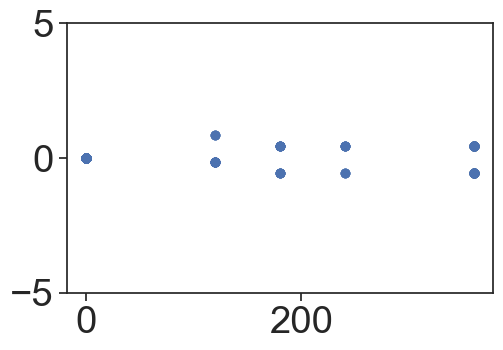

In [113]:
# indicate taht residual is not normally distributed and centre around 0
plt.plot(x, residuals, 'o')
plt.ylim(-5,5)

Text(0.5, 0, 'Time (min)')

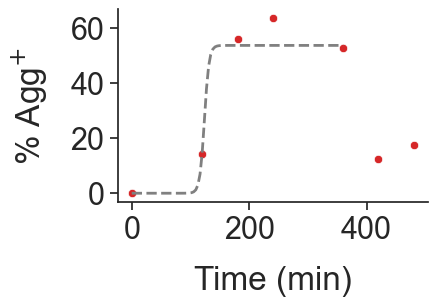

In [344]:
# dep = pd.read_csv('dep_test.csv')
sns.set(font_scale=2) 
sns.set_style("ticks")
plt.subplots(figsize = [4,2.5])

# x = dep['deprivation_duration'][:5]
x = filtered_df['deprivation_duration']
plot_x = np.linspace(x.min()-0.4, x.max(), 100)
plt.plot(plot_x, logistic(plot_x, *popt)* 100, 
         linewidth = 2,
         linestyle = 'dashed',
         color = 'gray')

dep = pd.read_csv('dep_test.csv')
sns.scatterplot(data=dep, x='deprivation_duration', y='percent', color = 'Tab:red')
sns.despine()
# plt.ylim(-5,60)
plt.yticks(np.arange(0, 61, 20))
plt.ylabel(r'% Agg$^{+}$',labelpad = 15)

plt.xlabel('Time (min)', labelpad=15)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/deprivation_time_refeed.pdf',
#             bbox_inches='tight', transparent=True)

In [346]:
dep

,Unnamed: 0,deprivation_duration,count,state_after,n,percent
0,4.0,0,21,Agg+,0,0.000000
1,0.0,120,14,Agg+,2,14.285714
2,1.0,180,16,Agg+,9,56.250000
3,2.0,240,11,Agg+,7,63.636364
4,3.0,360,133,Agg+,70,52.631579
5,NaN,420,16,Agg+,2,12.500000
6,NaN,480,17,Agg+,3,17.600000


In [347]:
# chi-square statistics
# 0-360 statistics
food_dep = dep[dep['deprivation_duration']<420]
chi2, p, dof, expected = stats.chi2_contingency([food_dep['n'], food_dep['count'] - food_dep['n']])
print(chi2, p)

# 360 - 480 statistics
refed_dep = dep[dep['deprivation_duration']>=360]
chi2, p, dof, expected = stats.chi2_contingency([refed_dep['n'], refed_dep['count'] - refed_dep['n']])
print(chi2, p)


27.99394559844473 1.2508221224651907e-05
15.084032706199888 0.0005303272160768449


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/2867341917.py:5: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  at = sns.stripplot(x = 'deprivation_duration', y = 'state_after_latency', data = df, color='tab:red', alpha=.5, zorder=1, edgecolor='gray',


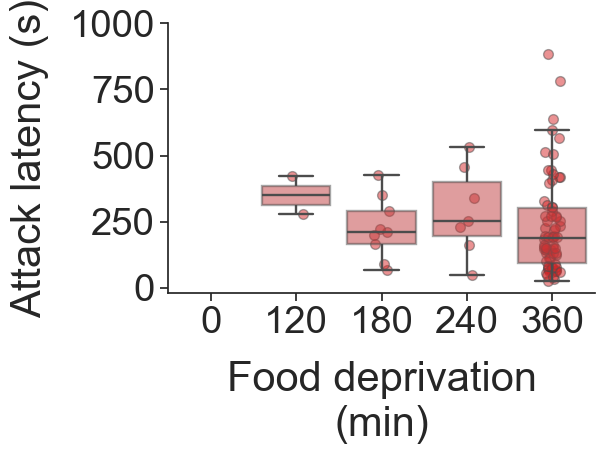

In [115]:
sns.set(rc={"figure.figsize": (5.5, 3.5)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

at = sns.stripplot(x = 'deprivation_duration', y = 'state_after_latency', data = df, color='tab:red', alpha=.5, zorder=1, edgecolor='gray',
                  jitter=True, dodge=False, marker='o', size=7, linewidth=1)
at = sns.boxplot(x = 'deprivation_duration', y = 'state_after_latency', data = df, color='tab:red', showfliers=False, linewidth=1.7,  boxprops=dict(alpha=.5))

    
at.set_ylabel('Attack latency (s)', labelpad=15)
at.set_xlabel('Food deprivation\n(min)', labelpad=15)
at.yaxis.set_major_locator(plt.MaxNLocator(5))
plt.ylim(top=1000)
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/deprivation_time_latency.pdf',
#             dpi=600, bbox_inches='tight', transparent=True)

In [116]:
df['state_after_latency'] = pd.to_numeric(df['state_after_latency'], errors='coerce')
df['deprivation_duration'] = df['deprivation_duration'].astype('category')

# Filter out the group with 0 hours of food deprivation
df_filtered = df[df['deprivation_duration'] != '0']

# Fit the ANOVA model on the filtered data
model = smf.ols('state_after_latency ~ C(deprivation_duration)', data=df_filtered).fit()
anova_results = sm.stats.anova_lm(model, typ=2)
print(anova_results)

# Check if the ANOVA is significant
if anova_results["PR(>F)"][0] < 0.05:
    print("The ANOVA is significant, indicating a relationship between food deprivation duration and attack latency.")
else:
    print("The ANOVA is not significant, indicating no relationship between food deprivation duration and attack latency.")

                               sum_sq    df          F        PR(>F)
C(deprivation_duration)  5.009957e+06   4.0  41.148808  4.661757e-19
Residual                 2.556796e+06  84.0        NaN           NaN
The ANOVA is significant, indicating a relationship between food deprivation duration and attack latency.


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/615748198.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_results["PR(>F)"][0] < 0.05:


In [117]:
#stats for latency
# model = smf.ols('state_after_latency ~ C(deprivation_duration)', data=df2).fit()
# sm.stats.anova_lm(model, typ=2)

In [118]:
# based on deprivation time, given that animal switch to be aggressive, what is the estrous cycle stage?
agg_df = df[df.state_after == 'Agg+']
estrous_dep = pd.crosstab(agg_df['deprivation_duration'], agg_df['estrous_stage'], margins = True).reset_index()
estrous_dep.iloc[:, 1:5] = estrous_dep.iloc[:, 1:5].div(estrous_dep.All, axis = 0) *100
estrous_dep = estrous_dep.iloc[:-1, :-1]
cols = ['deprivation_duration', 'P', 'E', 'M', 'D']
estrous_dep = estrous_dep[cols]

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/3294010382.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     0.000000
1    22.222222
2    14.285714
3    25.000000
4    22.727273
Name: D, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  estrous_dep.iloc[:, 1:5] = estrous_dep.iloc[:, 1:5].div(estrous_dep.All, axis = 0) *100
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/3294010382.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0    25.000000
1     0.000000
2     0.000000
3     8.823529
4     7.954545
Name: E, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  estrous_dep.iloc[:, 1:5] = estrous_dep.iloc[:, 1:5].div(estrous_dep.All, axis = 0) *100
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y

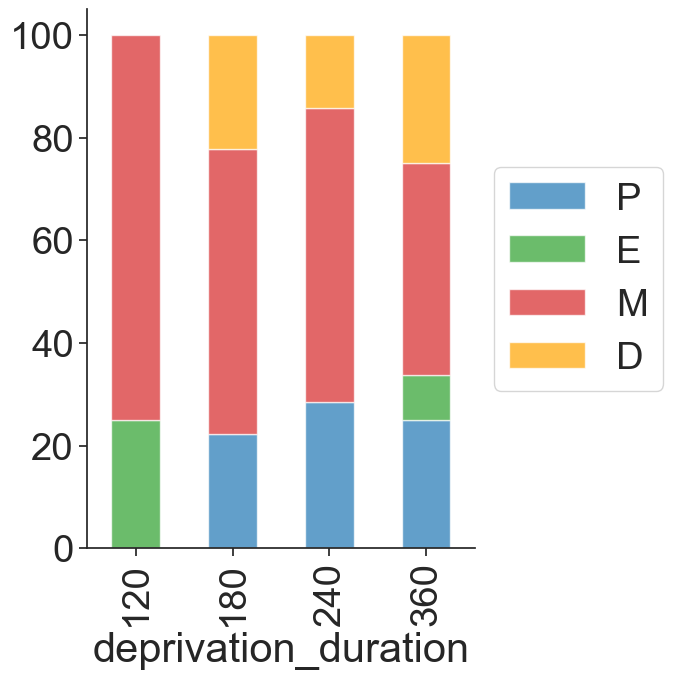

In [119]:
estrous_dep.plot(
          x = 'deprivation_duration', 
          kind = 'bar', 
          stacked = True,  
          mark_right = False,
          color = ['Tab:blue', 'Tab:green', 'Tab:red', 'orange'],
          figsize = (5,7), alpha = 0.7)

ax = plt.gca()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('output_figures/deprivation_time_hormone.jpeg', dpi = 300)

In [120]:
# how is switching probability differ in different estrous cyle per deprivation duration --> proportion plateau
df = pd.read_csv('deprivation_time.csv')
count = df.groupby(['deprivation_duration', 'estrous_stage'],dropna = False).size().unstack().fillna(0).stack().reset_index(name = 'count').dropna()
n = df.groupby(['deprivation_duration','estrous_stage', 'state_after'],dropna = False).size().unstack().fillna(0).stack().reset_index(name = 'n').dropna()
est_prop = count.merge(n, how = 'outer', on = ['deprivation_duration', 'estrous_stage'])
est_prop['percent'] = est_prop['n'] /est_prop['count'] *100
est_prop = est_prop.fillna(0)
est_prop['estrous_stage'] = pd.Categorical(est_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
est_prop['deprivation_duration'] = pd.Categorical(est_prop['deprivation_duration'], [0,120, 180,240,360])

est_prop = est_prop.sort_values(by = ['deprivation_duration', 'estrous_stage'])

/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


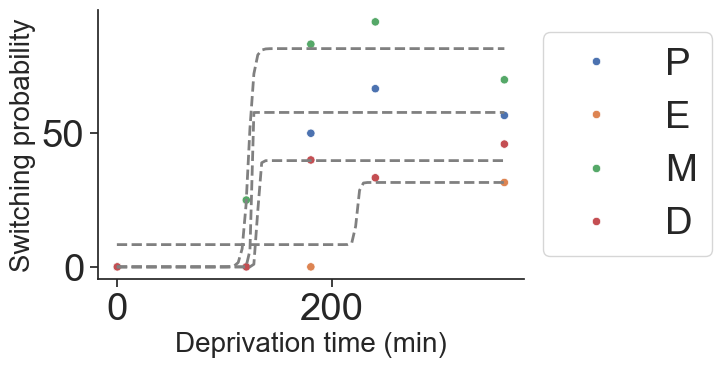

In [123]:
sns.scatterplot(data=est_prop[est_prop.state_after == 'Agg+'], x='deprivation_duration', y='percent', hue = 'estrous_stage',color = 'Tab:red')
As = {}
for stage in est_prop.estrous_stage.unique():
    fit_df = est_prop[(est_prop.state_after == 'Agg+') & (est_prop.estrous_stage == stage)]
    
    x = fit_df['deprivation_duration'].astype(int)
    y = fit_df['percent'].astype(float)
    
    try:
    #control for runtime error
        popt, pcov = curve_fit(logistic, x, y, p0=[50,185,0.1,0])
    except RuntimeError:
        continue
    As[stage] = popt[0]
    plot_x = np.linspace(x.min()-0.4, x.max(), 100)
    plt.plot(plot_x, logistic(plot_x, *popt), 
             linewidth = 2,
             linestyle = 'dashed',
             color = 'gray')
    plt.xlabel('Deprivation time (min)', fontsize = 20)
    plt.ylabel('Switching probability', fontsize = 20)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('output_figures/deprivation_time_hormone_SP.jpeg', dpi = 300)

# Environmental Factors for NPS Probability

In [124]:
bootstrap_sample = {}
sample = {}

for con in exp_conds:
    if con == 'food_deprivation':
        con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'cricket']
        con_data = con_data[con_data['exp_time'] == 1]
        con_data_binary = np.where(con_data.state_after.values == 'Agg+', 1, 0)
        bootstrap_sample[con] = bootstrap(con_data_binary)
        sample[con] = [len(con_data[con_data.state_after =='Agg+']),
                      len(con_data[con_data.state_after =='Agg-'])]
    else:
        con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'pup']
        con_data = con_data[con_data['exp_time'] == 1]
        con_data_binary = np.where(con_data.state_after.values == 'Agg+', 1, 0)
        bootstrap_sample[con] = bootstrap(con_data_binary)
        sample[con] = [len(con_data[con_data.state_after =='Agg+']),
                      len(con_data[con_data.state_after =='Agg-'])]

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/764886534.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'pup']
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/764886534.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'pup']
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/764886534.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'pup']
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/764886534.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'pup']
/var

## stats comparing proportion of Agg+ mice experiencing different environmental conditions

In [125]:
itertool_stats(sample, 'fisher')

('all_stressor_5h', 'all_stressor_2h') 0.079075857511717
('all_stressor_5h', 'food_deprivation') 1.0
('all_stressor_5h', 'water_deprivation') 0.009495955652908138
('all_stressor_5h', 'light_cycle_disturbed') 0.0030159009564043895
('all_stressor_5h', 'novel_env') 0.003894960874365908
('all_stressor_5h', 'all_stressor_plus_food') 0.009495955652908138
('all_stressor_2h', 'food_deprivation') 0.03347242787275093
('all_stressor_2h', 'water_deprivation') 1.0
('all_stressor_2h', 'light_cycle_disturbed') 0.4210526315789473
('all_stressor_2h', 'novel_env') 0.4444444444444444
('all_stressor_2h', 'all_stressor_plus_food') 1.0
('food_deprivation', 'water_deprivation') 0.006428533551968739
('food_deprivation', 'light_cycle_disturbed') 0.0010548481944362951
('food_deprivation', 'novel_env') 0.002554532558570787
('food_deprivation', 'all_stressor_plus_food') 0.006428533551968739
('water_deprivation', 'light_cycle_disturbed') 1.0
('water_deprivation', 'novel_env') 1.0
('water_deprivation', 'all_stresso

In [126]:
# chi2_contingency

test_df = pd.DataFrame(sample)
stats.chi2_contingency(test_df.loc[:, ['all_stressor_5h', 'food_deprivation', 'water_deprivation','light_cycle_disturbed', 'novel_env', 'all_stressor_plus_food']])

Chi2ContingencyResult(statistic=30.473486842105267, pvalue=1.1898286106365005e-05, dof=5, expected_freq=array([[ 4.4057971 ,  4.4057971 ,  2.20289855,  3.02898551,  2.75362319,
         2.20289855],
       [11.5942029 , 11.5942029 ,  5.79710145,  7.97101449,  7.24637681,
         5.79710145]]))

## visualization of environmental condition based probability of mice turning to be aggressive

In [127]:
# compute agg proportion for each condition
agg_plus_proportion = {}
agg_minus_proportion = {}
ns = {}

for con in exp_conds:
    if con == 'all_stressor_2h':
        pass
    elif con == 'food_deprivation':
        con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'cricket']
        ns[con] = len(con_data)
        row_count = len(con_data)
        agg_count = len(con_data[con_data['state_after'] == 'Agg+']) 
        agg_plus_proportion[con] = agg_count / row_count * 100
        agg_minus_proportion[con] = 100 - agg_plus_proportion[con]
        
    else:
        con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'pup']
        ns[con] = len(con_data)
        row_count = len(con_data)
        agg_count = len(con_data[con_data['state_after'] == 'Agg+']) 
        agg_plus_proportion[con] = agg_count / row_count * 100
        agg_minus_proportion[con] = 100 - agg_plus_proportion[con]

print(agg_plus_proportion)

{'all_stressor_5h': 56.25, 'food_deprivation': 62.5, 'water_deprivation': 0.0, 'light_cycle_disturbed': 0.0, 'novel_env': 0.0, 'all_stressor_plus_food': 0.0}


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/4097251771.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'pup']
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/4097251771.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'pup']
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/4097251771.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'cricket']
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/4097251771.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  con_data = data[data['exp_cond'] == con][data['exp_time'] == 1][data['target'] == 'cr

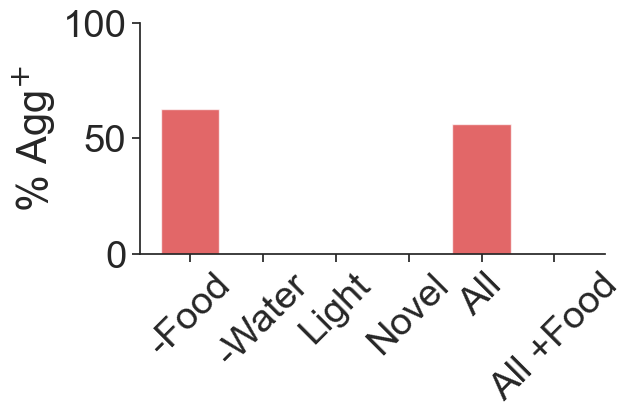

In [129]:
sns.set(rc={"figure.figsize": (6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

order = ['food_deprivation', 'water_deprivation', 'light_cycle_disturbed', 'novel_env', 'all_stressor_5h', 'all_stressor_plus_food']
values = [agg_plus_proportion[key] for key in order]
plt.bar(range(len(values)), values, tick_label=order, align='center', color='tab:red', alpha=0.7)
plt.xlabel(None)
plt.ylabel(r'% Agg$^{+}$')
    
locs, labels = plt.xticks()
plt.xticks(locs, ['-Food', '-Water', 'Light', 'Novel', 'All', 'All +Food'])
plt.xticks(rotation = 45)
plt.ylim(0, 100)
sns.despine()

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/hunger.pdf',
#             dpi=600,bbox_inches='tight', transparent=True)

In [130]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# access counts for agg / non-agg for each condition
agg_plus_counts = {}
agg_minus_counts = {}
total_counts = {}

for con in exp_conds:
    if con == 'all_stressor_2h':
        pass
    elif con == 'food_deprivation':
        con_data = data[(data['exp_cond'] == con) & (data['exp_time'] == 1) & (data['target'] == 'cricket')]
        total_counts[con] = len(con_data)
        agg_plus_counts[con] = con_data[con_data['state_after'] == 'Agg+'].shape[0]
        agg_minus_counts[con] = total_counts[con] - agg_plus_counts[con]
    else:
        con_data = data[(data['exp_cond'] == con) & (data['exp_time'] == 1) & (data['target'] == 'pup')]
        total_counts[con] = len(con_data)
        agg_plus_counts[con] = con_data[con_data['state_after'] == 'Agg+'].shape[0]
        agg_minus_counts[con] = total_counts[con] - agg_plus_counts[con]

# Define groups for comparison
comparison_groups = ['food_deprivation', 'all_stressor_5h']

# Initialize dictionary to store results of Fisher's exact tests
results = {}

# Perform Fisher's exact test for each comparison
for group in comparison_groups:
    other_groups = [g for g in agg_plus_counts.keys() if g != group]
    for other_group in other_groups:
        table = [[agg_plus_counts[group], agg_minus_counts[group]],
                 [agg_plus_counts[other_group], agg_minus_counts[other_group]]]
        odds_ratio, p_value = fisher_exact(table)
        results[f"Fisher's exact test between '{group}' and '{other_group}'"] = {'odds_ratio': odds_ratio, 'p_value': p_value}

# Perform Benjamini-Hochberg correction
p_values = [result['p_value'] for result in results.values()]
corrected_p_values = multipletests(p_values, method='fdr_bh')[1]

# Update the results dictionary with corrected p-values
for i, (comparison, result) in enumerate(results.items()):
    result['corrected_p_value'] = corrected_p_values[i]

# Print corrected p-values
for comparison, result in results.items():
    print(f"{comparison}:")
    print(f"Odds Ratio: {result['odds_ratio']}, p-value: {result['p_value']}, Corrected p-value: {result['corrected_p_value']}")
    print()

Fisher's exact test between 'food_deprivation' and 'all_stressor_5h':
Odds Ratio: 1.2962962962962963, p-value: 1.0, Corrected p-value: 1.0

Fisher's exact test between 'food_deprivation' and 'water_deprivation':
Odds Ratio: inf, p-value: 0.006428533551968739, Corrected p-value: 0.010714222586614565

Fisher's exact test between 'food_deprivation' and 'light_cycle_disturbed':
Odds Ratio: inf, p-value: 0.0010548481944362951, Corrected p-value: 0.009737402185914769

Fisher's exact test between 'food_deprivation' and 'novel_env':
Odds Ratio: inf, p-value: 0.002554532558570787, Corrected p-value: 0.009737402185914769

Fisher's exact test between 'food_deprivation' and 'all_stressor_plus_food':
Odds Ratio: inf, p-value: 0.006428533551968739, Corrected p-value: 0.010714222586614565

Fisher's exact test between 'all_stressor_5h' and 'food_deprivation':
Odds Ratio: 0.7714285714285715, p-value: 1.0, Corrected p-value: 1.0

Fisher's exact test between 'all_stressor_5h' and 'water_deprivation':
Odd

# the effect of spontaneous state on NPS

## compute the probability of Agg+ mice depending on the spontaneous parental state

In [131]:
tar_data = data[data.target.isin(['pup', 'maze', 'intruder', 'cricket', 'cfos', 'refeeding_1h', 'refeeding_2h', 'openfield'])]
agg_cond_data = pd.concat([tar_data[tar_data['exp_cond'] == agg_conds[0]], 
                    tar_data[tar_data['exp_cond'] == agg_conds[1]]])
agg_cond_data_first = agg_cond_data[agg_cond_data['exp_time'] == 1]

con_spon_ig, n_ig = compute_conditional(agg_cond_data_first, 'Agg+','state_after', 'Parental-','state_before')
con_spon_parental, n_parental = compute_conditional(agg_cond_data_first, 'Agg+','state_after','Parental+','state_before')
n = [n_ig, n_parental]
print(n)
print(con_spon_ig, con_spon_parental)

[67, 66]
0.5671641791044776 0.48484848484848486


In [132]:
# stats to see whether the spontaneous state differentially affect the likelihood of being aggressive
spon_df = agg_cond_data_first.copy()
spon_df.loc[spon_df.state_after == 'Agg-', 'state_after'] = spon_df.loc[spon_df.state_after == 'Agg-', 'parental_state_after']
spon_table = pd.crosstab(spon_df.state_before, spon_df.state_after)
spon_chi, spon_p, dof, expected = stats.chi2_contingency(spon_table)
spon_table = spon_table.reset_index()
print(spon_table)
print(spon_chi, spon_p, dof)

state_after state_before  Agg+  Parental+  Parental-
0              Parental+    32         30          4
1              Parental-    38          9         18
20.72464300268496 3.160100919462887e-05 2


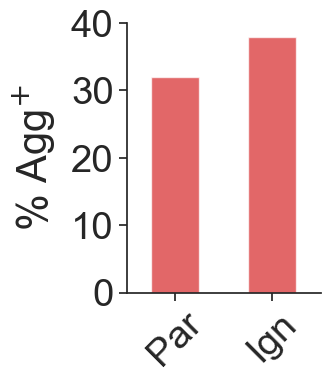

In [133]:
sns.set(rc={"figure.figsize": (2.5, 3.5)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

spon = spon_table.plot(
          x = 'state_before',
          y = 'Agg+',  
          kind = 'bar', 
          color = ['Tab:red', 'Tab:red'],
          alpha = 0.7)
spon.set_xticklabels( ('Par', 'Ign'), rotation=45)
plt.ylabel(r'% Agg$^{+}$', labelpad=10)
spon.set_xlabel('')
plt.ylim(top=40)
spon.yaxis.set_major_locator(plt.MaxNLocator(4))
spon.legend_.remove()
sns.despine()

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/spontaneous_state.pdf',
#             dpi=600,bbox_inches='tight', transparent=True)

# Estrous stages and NPS Probability

## impact of estrous cycle on the proportion of spontaneous parental and ignoring mice

In [134]:
est_spon_ig = {}
est_spon_parental = {}
n_spon_ig = {}
n_spon_parental = {}

data_est = tar_data[tar_data['exp_time'] == 1]

for estrous_stage in estrous_stages:
    est_data = data_est[data_est['estrous_stage'] == estrous_stage]
    est_data = est_data[est_data['exp_time'] == 1]
    est_spon_ig_data = est_data[est_data['state_before'] == 'Parental-']
    est_spon_parental_data = est_data[est_data['state_before'] == 'Parental+']
    est_spon_ig[estrous_stage] = len(est_spon_ig_data) / len(est_data)
    n_spon_ig[estrous_stage] = len(est_spon_ig_data)
    est_spon_parental[estrous_stage] = len(est_spon_parental_data) / len(est_data)
    n_spon_parental[estrous_stage] = len(est_spon_parental_data)
    

## plot proportion of mice being spontaneous parental or ignoring under different estrous cycle stage

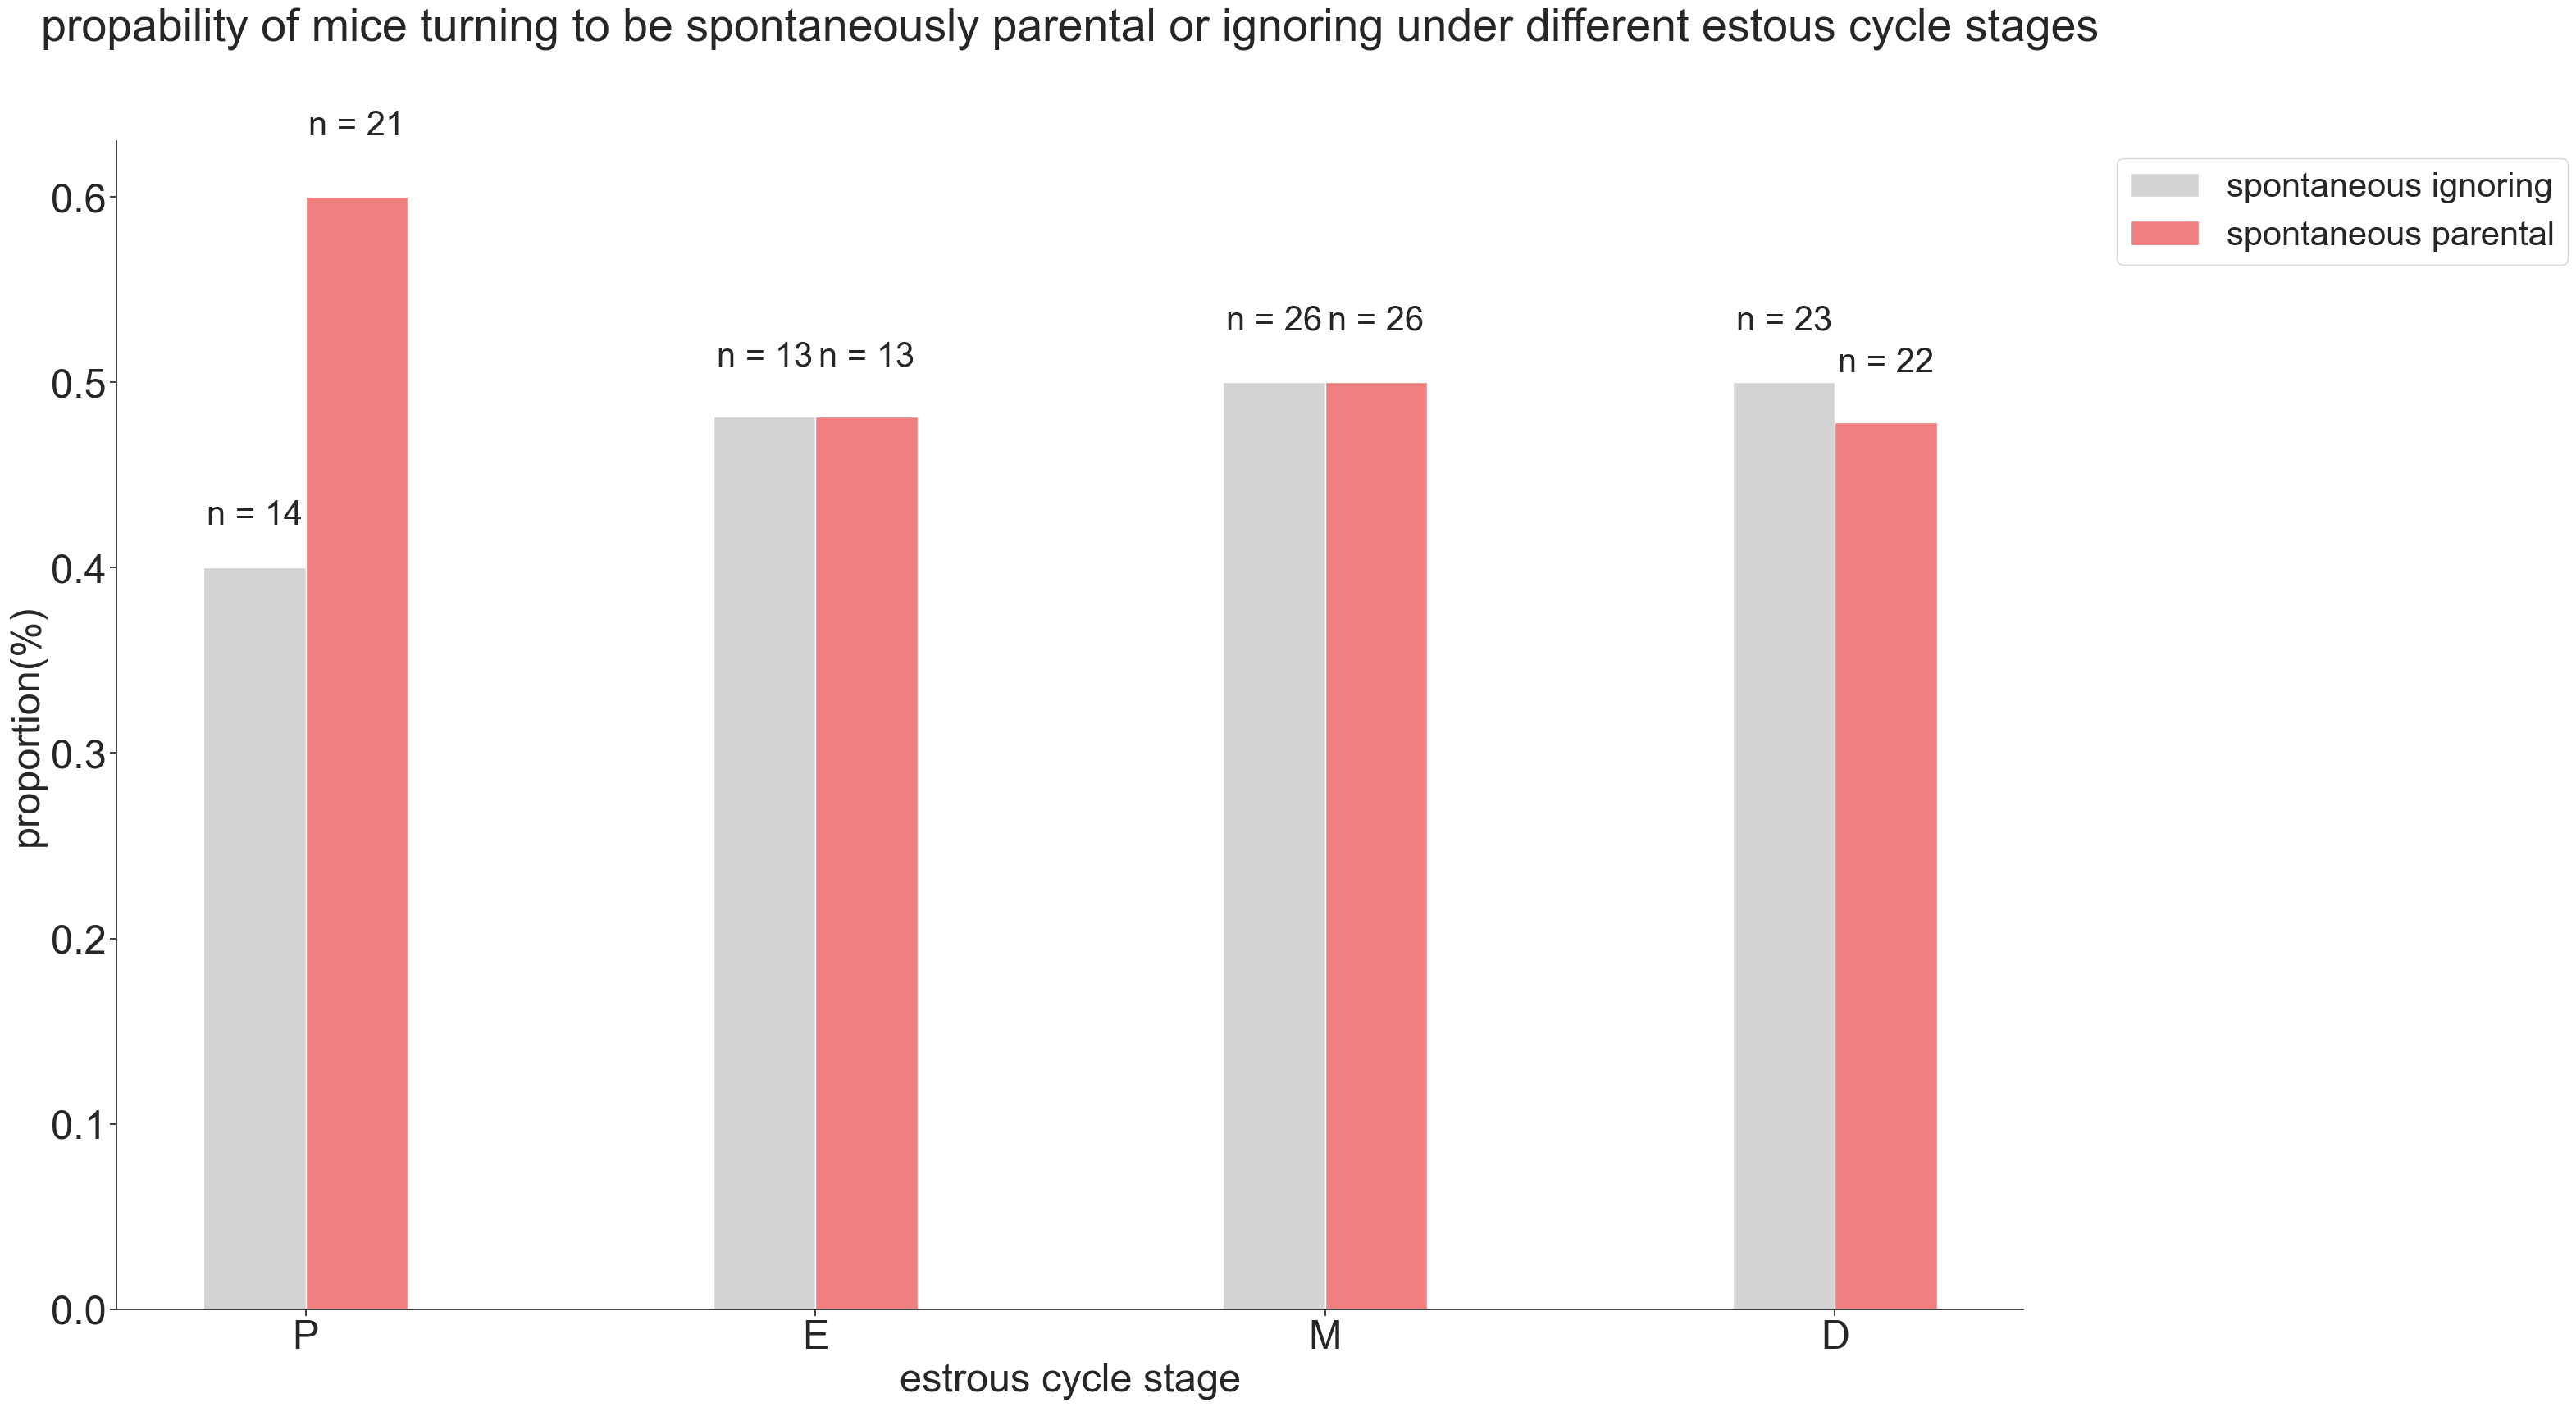

In [135]:
fig, ax = plt.subplots(figsize = (30, 18.5))
plt.rcParams['axes.facecolor'] = 'white'
w = 0.1
x = np.arange(len(est_spon_parental))

est_spon_ig_fig = ax.bar(x - w, list(est_spon_ig.values()),
                        align = 'center', color = 'lightgray', width = 0.2)
i = 0
for position in est_spon_ig_fig:
    plt.text(position.get_x() + position.get_width()/2., 1.05 * position.get_height(),
            'n = ' + str(list(n_spon_ig.values())[i]) ,ha='center', va='bottom', fontsize = 30)
    i += 1

    
est_spon_parental_fig = ax.bar(x + w, list(est_spon_parental.values()),
                            align = 'center', 
                            color = 'lightcoral', width = 0.2)
i = 0
for position in est_spon_parental_fig:
    plt.text(position.get_x() + position.get_width()/2., 1.05 * position.get_height(),
            'n = ' + str(list(n_spon_parental.values())[i]) ,ha='center', va='bottom', fontsize = 30)
    i += 1
    
    
ax.legend(['spontaneous ignoring', 'spontaneous parental'], bbox_to_anchor = (1.04, 1), 
           loc = 'upper left', fontsize = 30)
ax.set_xlabel('estrous cycle stage', fontsize = 35)
ax.set_ylabel('proportion(%)', fontsize = 35)
ax.set_title('propability of mice turning to be spontaneously parental or ignoring under different estous cycle stages',
         fontsize = 40, y = 1.08)

ax.set_xticks(x)
ax.set_xticklabels(list(est_spon_ig.keys()),fontsize = 35)  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis="y", labelsize = 35)

plt.show()

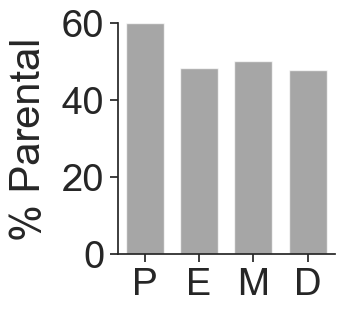

In [136]:
# convert dict to df, convert to %
est_spon_parental_df = pd.DataFrame([est_spon_parental])*100

sns.set(rc={"figure.figsize": (2.8, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.barplot(data = est_spon_parental_df, color = 'gray', width = 0.7, alpha = 0.7)
plt.ylabel('% Parental', labelpad=10)
spon.set_xlabel('')
plt.ylim(top=60)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
sns.despine()

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_4/linked_figure_S4/estrous_switch.pdf',
#             dpi=600,bbox_inches='tight', transparent=True)

## impact of estrous cycle on the proportion of mice turning to be aggressive

In [137]:
estrous_data = {}
ns = {}
ns_spon_ig = {}
ns_spon_parental = {}
agg_latency = {}
est_con_spon_ig = {}
est_con_spon_parental = {}
len_agg = {}


for estrous_stage in estrous_stages:
    # proportion of mice turning to be aggressive at different estrous cycle stage
    est_data = agg_cond_data_first[agg_cond_data_first['estrous_stage'] == estrous_stage]
    est_data_agg = est_data[est_data['state_after'] == 'Agg+']
    union_p = est_data_agg[est_data_agg['state_before'] =='Parental+']
    union_m = est_data_agg[est_data_agg['state_before'] =='Parental-']
    
    len_agg[estrous_stage] = len(est_data_agg)
    est_data_agg_latency = est_data_agg['state_after_latency']
    est_prop = len(est_data_agg) / len(est_data) * 100
    estrous_data[estrous_stage] = est_prop
    ns[estrous_stage] = len(est_data)
    agg_latency[estrous_stage] = est_data_agg_latency
    
    # conditional propability of mice turning to be aggressivce at different estrous cycle stage
    est_con_spon_ig[estrous_stage] = compute_conditional(est_data, 'Agg+','state_after', 'Parental-', 'state_before')[0]
    ns_spon_ig[estrous_stage] = len(est_data[est_data['state_before'] == 'Parental-'])
    est_con_spon_parental[estrous_stage] = compute_conditional(est_data, 'Agg+','state_after', 'Parental+','state_before')[0]
    ns_spon_parental[estrous_stage] = len(est_data[est_data['state_before'] == 'Parental+'])

print(estrous_data)
print(est_con_spon_ig)
print(est_con_spon_parental) 
print(ns) 
# estrous_data = pd.DataFrame.from_dict(estrous_data, orient = 'index')
# estrous_data.to_csv('generated_datasets/estrous_data.csv')

{'P': 56.666666666666664, 'E': 31.57894736842105, 'M': 70.0, 'D': 45.94594594594595}
{'P': 0.6923076923076923, 'E': 0.6, 'M': 0.6818181818181818, 'D': 0.42105263157894735}
{'P': 0.47058823529411764, 'E': 0.0, 'M': 0.7222222222222222, 'D': 0.5}
{'P': 30, 'E': 19, 'M': 40, 'D': 37}


## infer statistical power

In [138]:
stats.chi2_contingency([[len_agg['P'], ns['P'] - len_agg['P']],
                        [len_agg['E'], ns['E'] - len_agg['E']],
                        [len_agg['M'], ns['M'] - len_agg['M']],
                        [len_agg['D'], ns['D'] - len_agg['D']]])

Chi2ContingencyResult(statistic=9.01868015661653, pvalue=0.029043551899317763, dof=3, expected_freq=array([[16.19047619, 13.80952381],
       [10.25396825,  8.74603175],
       [21.58730159, 18.41269841],
       [19.96825397, 17.03174603]]))

In [139]:
pvalues = []
for subset in itertools.combinations(estrous_data.keys(), 2):
    stat, p = stats.fisher_exact([[len_agg[subset[0]], ns[subset[0]] - len_agg[subset[0]]],
                                        [len_agg[subset[1]], ns[subset[1]] - len_agg[subset[1]]]])
    pvalues.append(p)
    print(subset, stat,p)

from statsmodels.stats.multitest import multipletests
_, corrected_p_values, _, _ = multipletests(pvalues, method='fdr_bh')
print("Corrected p-values:", corrected_p_values)

('P', 'E') 2.8333333333333335 0.14153015693498766
('P', 'M') 0.5604395604395604 0.31590881582598795
('P', 'D') 1.5384615384615385 0.4640757467918988
('E', 'M') 0.1978021978021978 0.01018033314318151
('E', 'D') 0.5429864253393665 0.39358049402449746
('M', 'D') 2.7450980392156863 0.039453911982237175
Corrected p-values: [0.28306031 0.46407575 0.46407575 0.061082   0.46407575 0.11836174]


## plot proportion turning to be aggressive vs estrous stages

{'P': 56.666666666666664, 'E': 31.57894736842105, 'M': 70.0, 'D': 45.94594594594595}


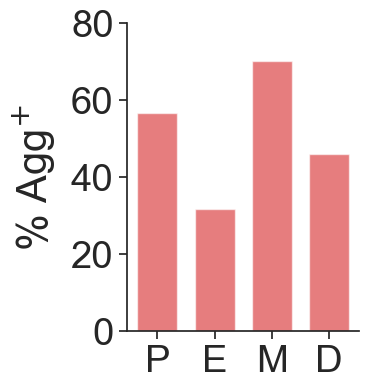

In [141]:
sns.set(font_scale=2.5)
sns.set_style("ticks")

fig, ax = plt.subplots(figsize = (3, 4))

print(estrous_data)
fig = plt.bar(range(len(estrous_data)), list(estrous_data.values()),
        tick_label = list(estrous_data), align = 'center', 
        color = 'Tab:red', width = 0.7, alpha = 0.6)

plt.xlabel('')
plt.ylabel(r'% Agg$^{+}$', labelpad=10)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 80)
# ax.tick_params(bottom=False)
sns.despine(bottom=False, trim=False)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/estrous_cycle.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)
plt.savefig('output_figures/estrous_cycle.png', dpi = 300, bbox_inches='tight', transparent=True)

## plot conditional probability of mice turning to be aggressivce 

In [142]:
for stage in estrous_stages:
    est_data = agg_cond_data_first[agg_cond_data_first['estrous_stage'] == stage]
    tab = pd.crosstab(est_data.state_before, est_data.state_after)
    odds, p  = stats.fisher_exact(tab)
    print(stage, p)

P 0.28275666677939226
E 0.0108359133126935
M 1.0
D 0.7458545854734855


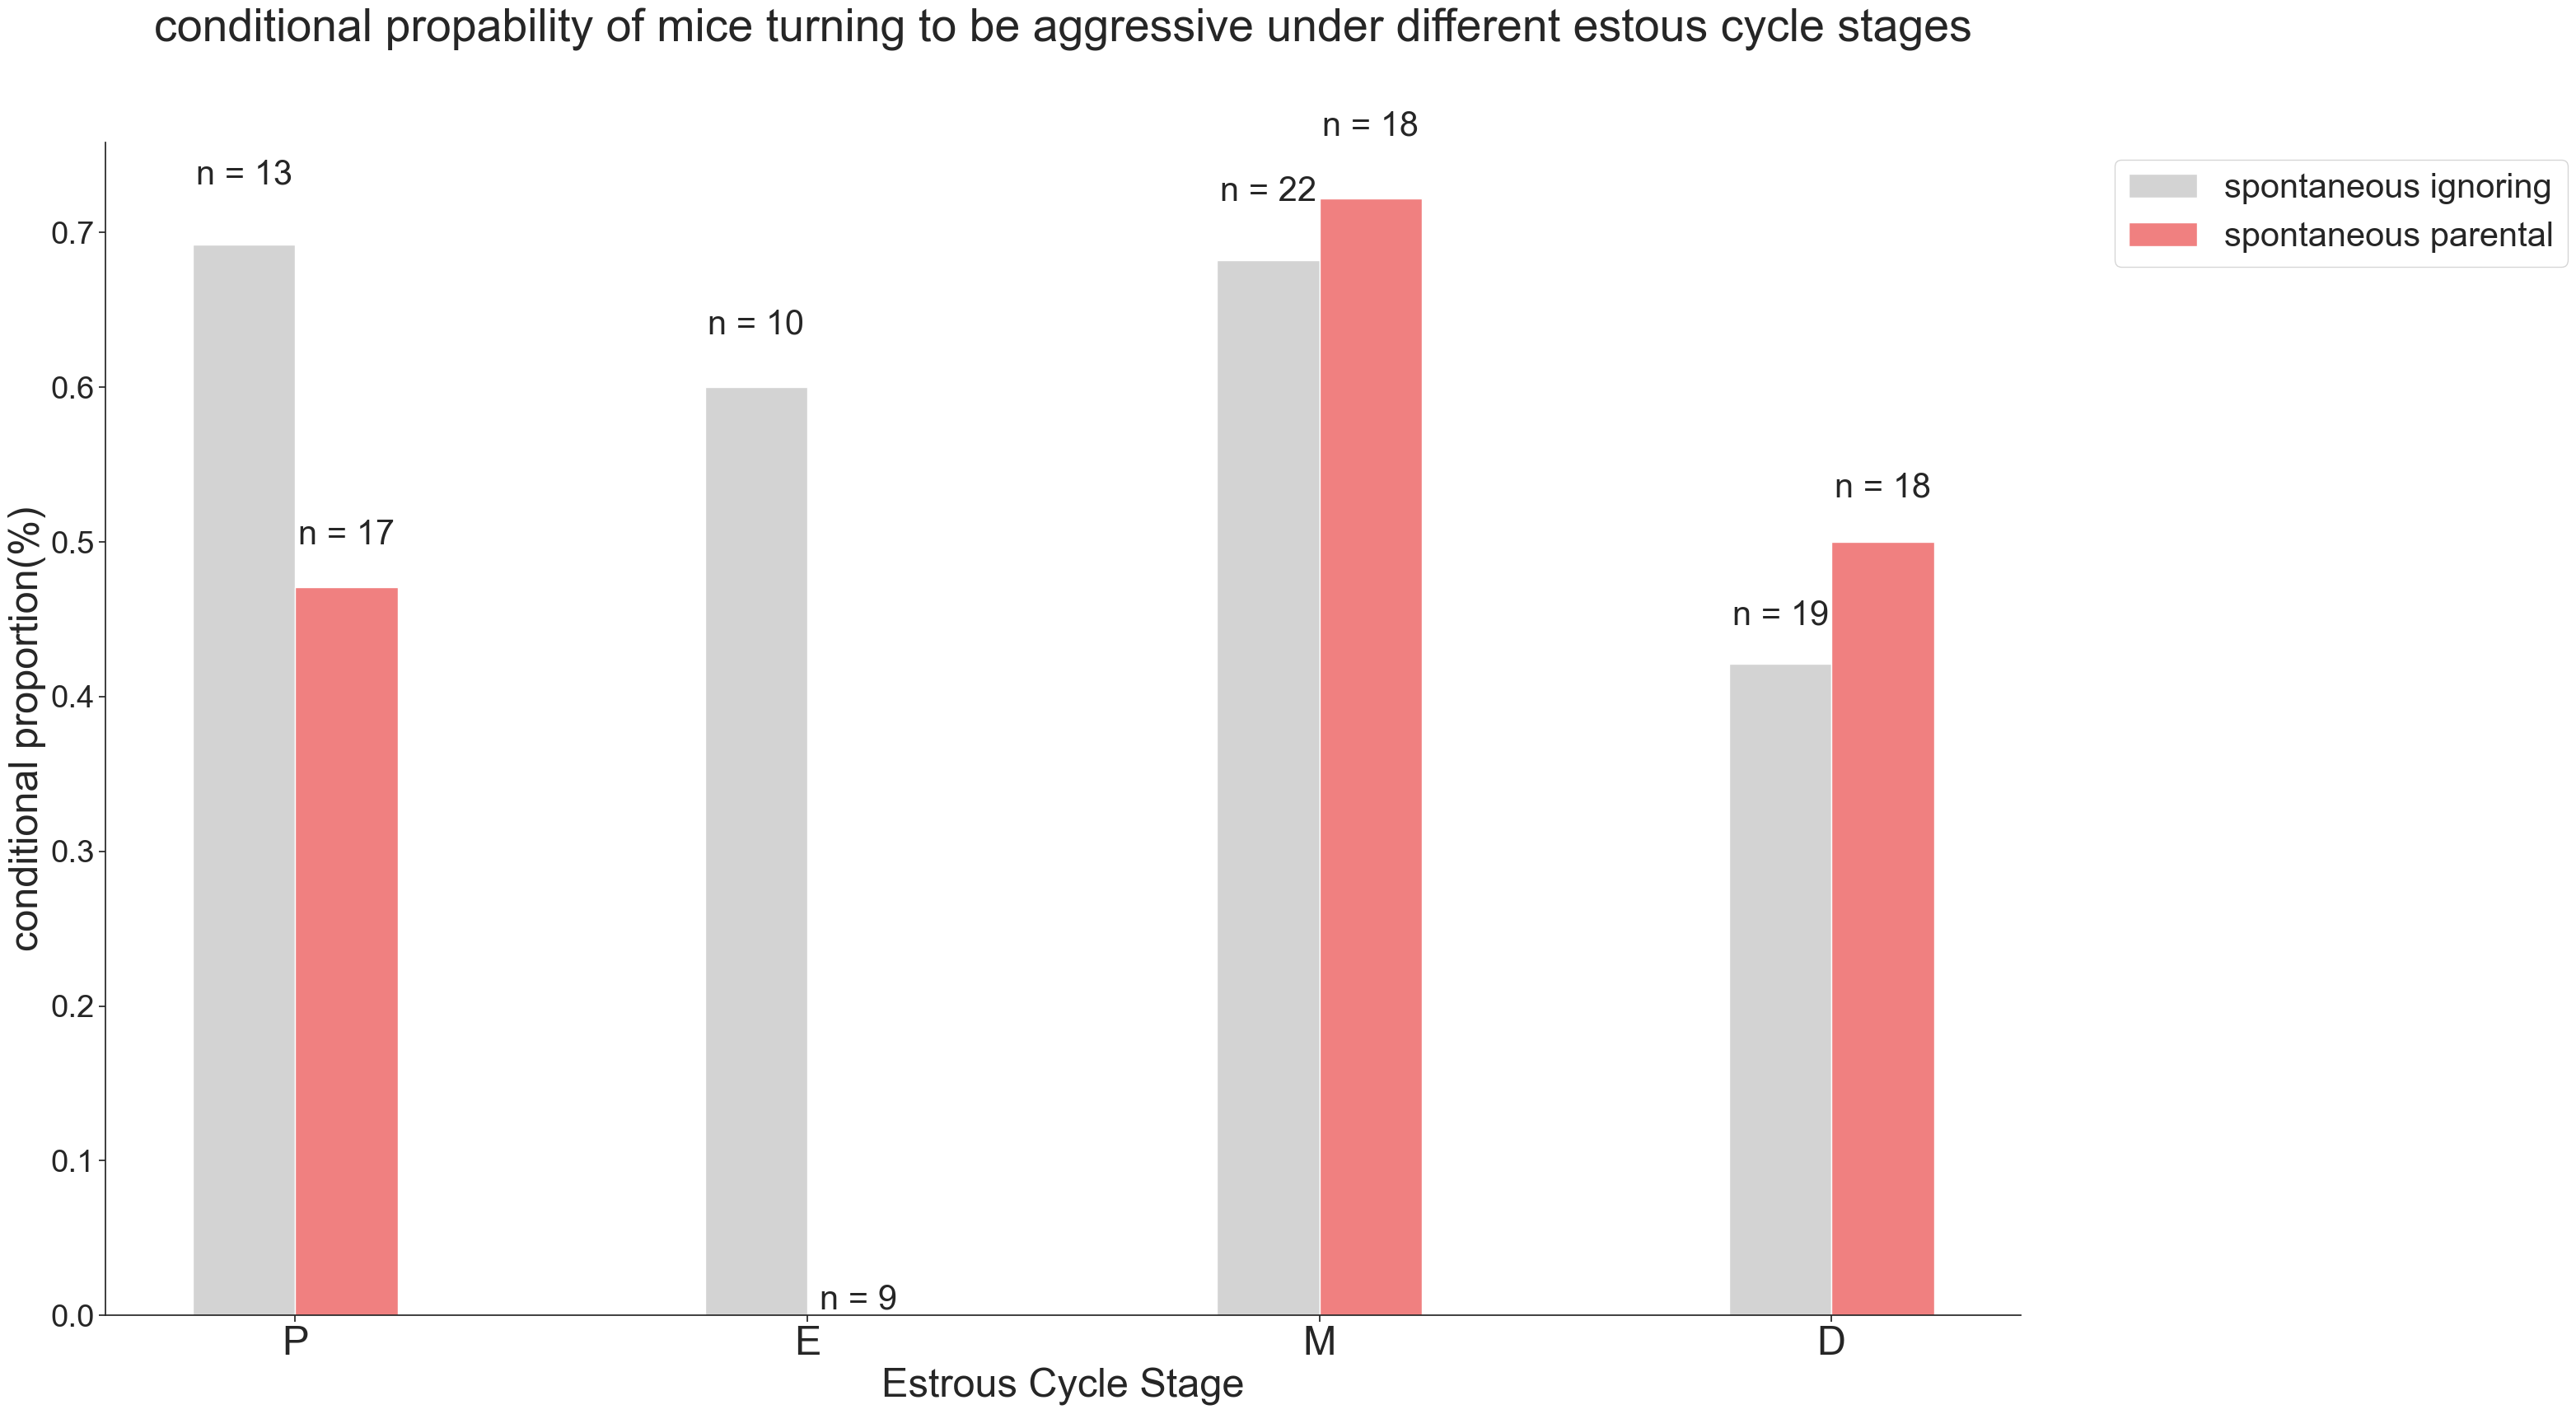

In [143]:
fig, ax = plt.subplots(figsize = (30, 18.5))
plt.rcParams['axes.facecolor'] = 'white'
w = 0.1
x = np.arange(len(est_con_spon_parental))

est_con_spon_ig_fig = ax.bar(x - w, list(est_con_spon_ig.values()),
                              align = 'center', color = 'lightgray', width = 0.2)
i = 0
for position in est_con_spon_ig_fig:
    plt.text(position.get_x() + position.get_width()/2., 1.05 * position.get_height(),
            'n = ' + str(list(ns_spon_ig.values())[i]) ,ha='center', va='bottom', fontsize = 30)
    i += 1

    
est_con_spon_parental_fig = ax.bar(x + w, list(est_con_spon_parental.values()),
                            align = 'center', color = 'lightcoral', width = 0.2)
i = 0
for position in est_con_spon_parental_fig:
    plt.text(position.get_x() + position.get_width()/2., 1.05 * position.get_height(),
            'n = ' + str(list(ns_spon_parental.values())[i]) ,ha='center', va='bottom', fontsize = 30)
    i += 1
    
    
ax.legend(['spontaneous ignoring', 'spontaneous parental'], bbox_to_anchor = (1.04, 1), 
           loc = 'upper left', fontsize = 30)
ax.set_xlabel('Estrous Cycle Stage', fontsize = 35)
ax.set_ylabel('conditional proportion(%)', fontsize = 35)
ax.set_title('conditional propability of mice turning to be aggressive under different estous cycle stages',
         fontsize = 40, y = 1.08)

ax.set_xticks(x)
ax.set_xticklabels(list(est_con_spon_ig.keys()),fontsize = 35)
#ax.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0],fontsize = 35)  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('output_figures/spontaneous_estrous_state.jpg', dpi = 300, bbox_inches='tight')
plt.show()

## plot aggression latency vs estrous stages

In [144]:
tab_agg_latency = {}
for i in estrous_stages:
    tab_agg_latency[i] = agg_cond_data_first[agg_cond_data_first['estrous_stage'] == i]['state_after_latency'].dropna()

itertool_stats(tab_agg_latency, 'ttest')

('P', 'E') 0.6630991803989916
('P', 'M') 0.6573909173169192
('P', 'D') 0.5017855340552401
('E', 'M') 0.8035990614731735
('E', 'D') 0.9161957718691655
('M', 'D') 0.7693419187299397


In [145]:
stats.f_oneway(tab_agg_latency['P'], tab_agg_latency['E'], tab_agg_latency['M'], tab_agg_latency['D'])


F_onewayResult(statistic=0.1799905252610932, pvalue=0.9095994251297107)

In [146]:
group_counts = agg_cond_data_first['estrous_stage'].value_counts()
print(group_counts)

estrous_stage
M    40
D    37
P    30
E    19
Name: count, dtype: int64


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/2991425807.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='estrous_stage', y='state_after_latency', data = agg_cond_data_first, order=['P', 'E', 'M', 'D'], saturation=8,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/2991425807.py:5: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(x='estrous_stage', y='state_after_latency', data = agg_cond_data_first, order=['P', 'E', 'M', 'D'], saturation=8,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/2991425807.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effe

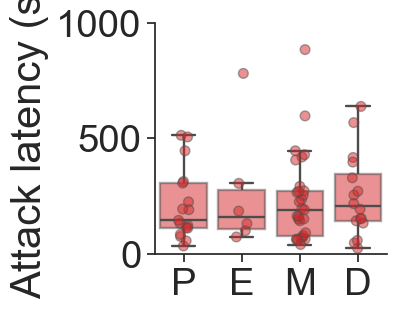

In [147]:
sns.set(rc={'figure.figsize':(3,3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='state_after_latency', data = agg_cond_data_first, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = ['Tab:red'], boxprops=dict(alpha=.5))
ax = sns.stripplot(x='estrous_stage', y='state_after_latency', data = agg_cond_data_first, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = ['Tab:red'], alpha=0.5)

ax.set_xlabel('')
ax.set_ylabel('Attack latency (s)', labelpad=5)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1000)
sns.despine(bottom=False)

    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_4/linked_figure_S4/estrous_latency.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/1144925285.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='state_before', y='state_after_latency', data = agg_cond_data_first, saturation=8,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/1144925285.py:2: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(x='state_before', y='state_after_latency', data = agg_cond_data_first, saturation=8,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/1144925285.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.stripplot(x='state_before', y='state_after

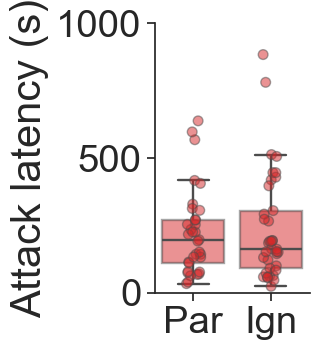

In [149]:
plt.subplots(figsize = (2, 3.5))
ax = sns.boxplot(x='state_before', y='state_after_latency', data = agg_cond_data_first, saturation=8, 
                 linewidth=1.7, showfliers = False, palette = ['Tab:red'], order = ['Parental+', 'Parental-'], boxprops=dict(alpha=.5))
ax = sns.stripplot(x='state_before', y='state_after_latency', data = agg_cond_data_first, jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray',  order = ['Parental+', 'Parental-'],palette = ['Tab:red'], alpha=0.5)

ax.set_xlabel('')
ax.set_xticklabels(['Par', 'Ign'])
ax.set_ylabel('Attack latency (s)', labelpad=5)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1000)
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/spontaneous_latency.pdf', dpi=300,bbox_inches='tight', transparent=True)

In [150]:
stats.mannwhitneyu(agg_cond_data_first[agg_cond_data_first['state_before'] == 'Parental+']['state_after_latency'].dropna(),
                   agg_cond_data_first[agg_cond_data_first['state_before'] == 'Parental-']['state_after_latency'].dropna())

MannwhitneyuResult(statistic=621.5, pvalue=0.9016793851442304)

## plot aggression latency versus spontaneous parental & ignoring

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/3519468112.py:3: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x = x,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/3519468112.py:11: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.swarmplot(x = x,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/3519468112.py:11: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(x = x,


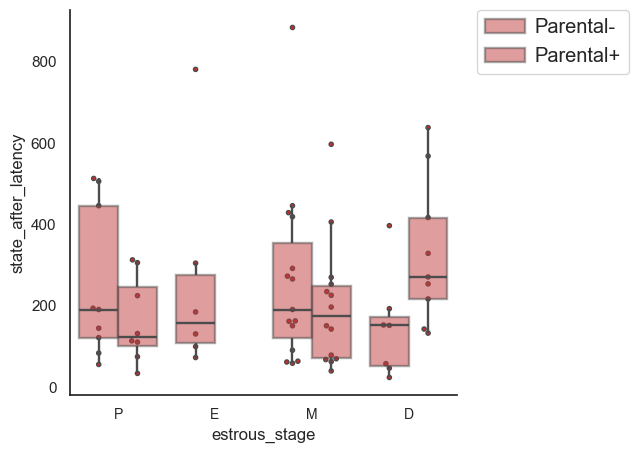

In [151]:
sns.set(rc={'figure.figsize':(5,5)})
sns.set_style("white")
order = estrous_stages


ax = category_plotting('estrous_stage', 
                  'state_after_latency',
                  'state_before', 
                  agg_cond_data_first, 
                  estrous_stages)
plt.xticks(fontsize = 10)
sns.despine()

# Relationship between P/E level and swiching probability 

## fit a function to the P/E curve

In [241]:
from scipy.optimize import curve_fit
from scipy.special import logit

# define function to be fitted 
def func(x, a,b,c,d):
    return a* np.log(b*x/(1-x)+c)+d


In [244]:
filtered_df = agg_cond_data_first.loc[:,['estrous_stage', 'state_after']]

filtered_df['state_after'] = filtered_df['state_after'].apply(lambda x: 1 if x == 'Agg+' else 0)
hormone = pd.read_csv('hormone_level/hormone.csv')
hormone.rename(columns = {'stage': 'estrous_stage'}, inplace = True)
hormone_df = pd.merge(filtered_df, hormone)
hormone_df['P/E* 10^-3'] = hormone_df['P/E* 10^-3']*0.1


x = hormone_df['P/E* 10^-3']
y = hormone_df['state_after']

# Estimate initial guesses for p0
a_guess = (np.max(y) - np.min(y)) / 2
b_guess = 1 / (np.max(x) - np.min(x))
c_guess = 1  # Small positive value to avoid log(0)
d_guess = np.min(y)

p0 = [a_guess, b_guess, c_guess, d_guess]


popt, pcov = curve_fit(func, x, y, p0=p0)

residuals = y- func(x, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)

0.07055593541405258


/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


fitting for deprivation time 120
fitting not successful for time 120
fitting for deprivation time 180
fitting for deprivation time 240
fitting for deprivation time 360


/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/scipy/optimize/_minpack_py

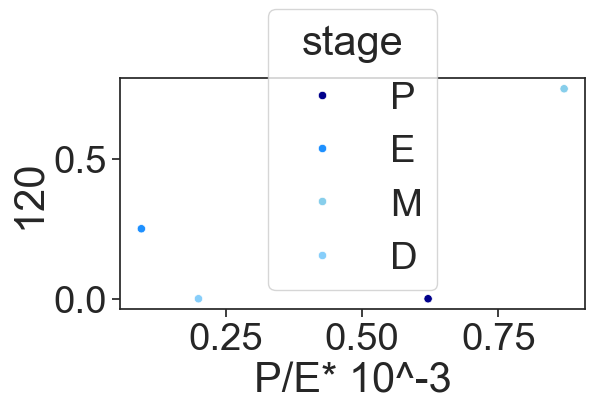

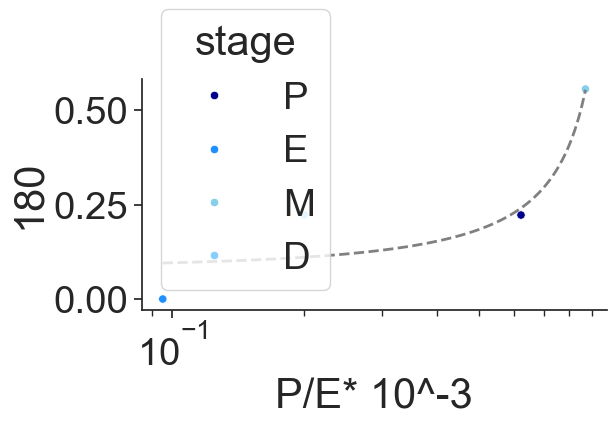

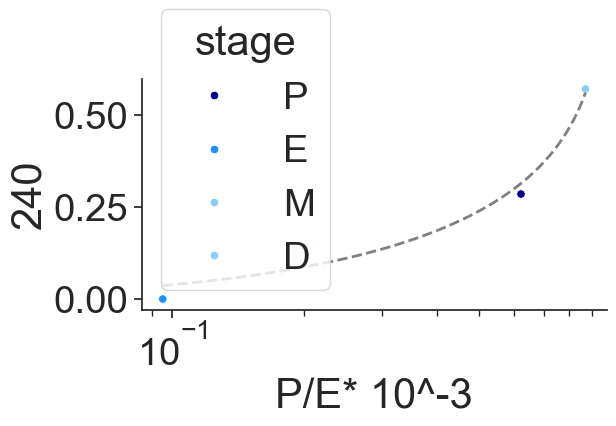

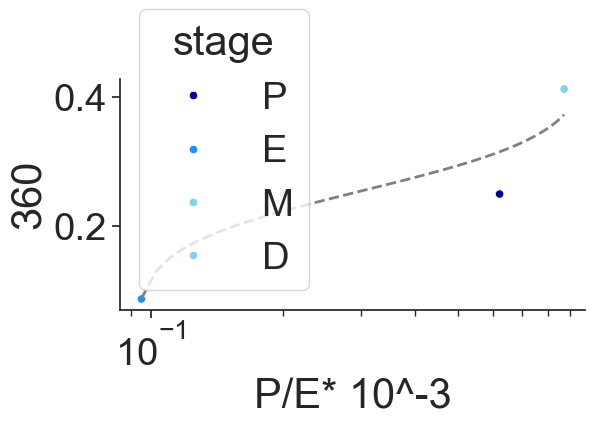

In [243]:
## temporary cells for tracing the effect of hormone on switching rate over time
hormone = pd.read_csv('hormone_level/hormone.csv')

columns = estrous_dep.T.reset_index().iloc[0][1:]
hormone_df = estrous_dep.T.iloc[1:,:]
hormone_df.columns = columns
hormone_df = hormone_df.reset_index()
hormone_df.rename(columns = {'estrous_stage':'stage'}, inplace = True)
hormone_df = pd.merge(hormone_df, hormone)
hormone_df['P/E* 10^-3'] = hormone_df['P/E* 10^-3']*0.1

for time in columns.unique()[:]:
    hormone_df[time] = hormone_df[time] *0.01

    try:
        print('fitting for deprivation time ' + str(time))
        
        fig, ax = plt.subplots(figsize = (6,3))
        sns.scatterplot(data=hormone_df, x='P/E* 10^-3', y=time, 
                        hue = 'stage', palette = ['darkblue', 'dodgerblue', 'skyblue', 'lightskyblue'])


        x = hormone_df['P/E* 10^-3']
        y = hormone_df[time]
        popt, pcov = curve_fit(func, x, y, p0=p0)

        plot_x = np.linspace(x.min(), x.max(), 100)
        plt.plot(plot_x, func(plot_x, *popt), 
                 linewidth = 2,
                 linestyle = 'dashed',
                 color = 'gray')
        plt.xscale("log")
        # plt.ylim([0,1])
        # plt.xlim([0.05,1])

        sns.despine()
        
    except RuntimeError:
        print('fitting not successful for time ' + str(time))
        
        

In [323]:
filtered_df = agg_cond_data_first.loc[:,['estrous_stage', 'state_after']]

filtered_df['state_after'] = filtered_df['state_after'].apply(lambda x: 1 if x == 'Agg+' else 0)
hormone = pd.read_csv('hormone_level/hormone.csv')
hormone.rename(columns = {'stage': 'estrous_stage'}, inplace = True)
hormone['P/E* 10^-3'] = hormone['P/E* 10^-3']* 0.1
hormone_df = pd.merge(filtered_df, hormone)


x = hormone_df['P/E* 10^-3']
y = hormone_df['state_after']

# Estimate initial guesses for p0
a_guess = (np.max(y) - np.min(y)) / 2
b_guess = 1 / (np.max(x) - np.min(x))
c_guess = 1 # Small positive value to avoid log(0)
d_guess = np.min(y)

p0 = [a_guess, b_guess, c_guess, d_guess]


popt, pcov = curve_fit(func, x, y, p0=p0)

residuals = y- func(x, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y-np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)


0.07055593541405258


/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [324]:
from scipy.stats import f

# Compute RSS for the full and null models
rss_full = np.sum((y - func(x, *popt))**2)
rss_null = np.sum((y - np.mean(y))**2)

# Degrees of freedom
k = len(popt)  # Number of parameters
n = len(y)     # Number of data points
df_model = k - 1
df_residual = n - k

# F-statistic
f_stat = ((rss_null - rss_full) / df_model) / (rss_full / df_residual)

# p-value
p_value_overall = 1 - f.cdf(f_stat, df_model, df_residual)
print(f"F-Statistic: {f_stat}")
print(f"Overall p-value: {p_value_overall}")


F-Statistic: 3.087087019181033
Overall p-value: 0.02978942456518241


In [325]:

# set up hormone state to include
preg = hormone[hormone.estrous_stage.isin(['PD10', 'PD18'])]
virgin = hormone[hormone.estrous_stage.isin(['P', 'E', 'M', 'D'])]



/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/955758641.py:6: RuntimeWarning: divide by zero encountered in divide
  return a* np.log(b*x/(1-x)+c)+d
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/955758641.py:6: RuntimeWarning: invalid value encountered in log
  return a* np.log(b*x/(1-x)+c)+d


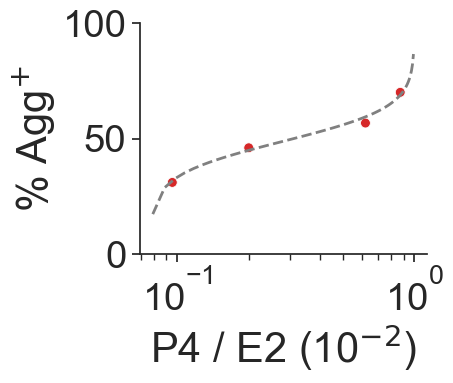

In [336]:
# %matplotlib inline
sns.set(rc={'figure.figsize':(3.7,3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

#reset the hormone dataframe


ax = sns.scatterplot(data=virgin, x='P/E* 10^-3', y='switching probability', s=50,
                hue = 'estrous_stage', palette = ['Tab:red', 'Tab:red', 'Tab:red', 'Tab:red'], legend=False)#darkblue', 'dodgerblue', 'skyblue', 'lightskyblue' 


# sns.scatterplot(data=preg, x='P/E* 10^-3', y='switching probability', hue = 'estrous_stage', 
#                 palette = ['lightcoral', 'indianred'])


# plot_x = np.linspace(x.min()-0.6, x.max() + 0.6, 100)
plot_x = np.linspace(0.05, 1, 100)
plt.plot(plot_x, func(plot_x, *popt) *100 , 
         linewidth = 2,
         linestyle = 'dashed',
         color = 'gray')


plt.xscale("log")
plt.xticks()
plt.yticks()
plt.ylim([0,100])

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel(r'P4 / E2 (10$^{-2}$)')
ax.set_ylabel(r'% Agg$^{+}$')
plt.savefig('output_figures/hormone_ratio.pdf', dpi = 300,bbox_inches='tight')
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_2/linked_figure2/hormone_ratio.pdf',
# dpi=600,bbox_inches='tight', transparent=True)

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/1761495537.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  virgin['switching probability_percent'] = virgin['switching probability']*100
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/1761495537.py:4: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.scatterplot(data=virgin, x='max_progesterone_level(ng/ml)', y='switching probability_percent',


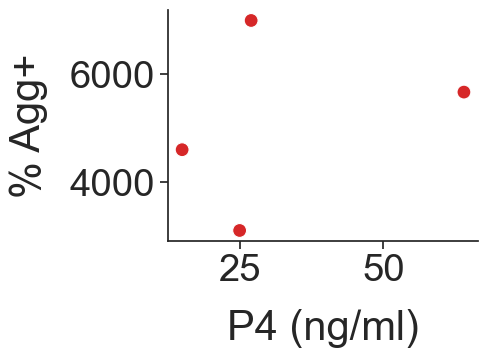

In [327]:
virgin['switching probability_percent'] = virgin['switching probability']*100
sns.set(font_scale=2.5, style = 'ticks')
plt.subplots(figsize = (4,3))
ax = sns.scatterplot(data=virgin, x='max_progesterone_level(ng/ml)', y='switching probability_percent', 
                hue = 'estrous_stage', s = 100,palette = ['Tab:red'])
ax.set_ylabel('% Agg+',fontsize = 30, labelpad=15)
ax.set_xlabel('P4 (ng/ml)',fontsize = 30, labelpad=15)

# turn legend off
ax.legend_.remove()
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_4/linked_figure_S4/P4_corr.pdf', dpi = 300,bbox_inches='tight',transparent=True)

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/3813952204.py:2: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.scatterplot(data=virgin, x='max_estrogen_level(pg/ml)', y='switching probability_percent',


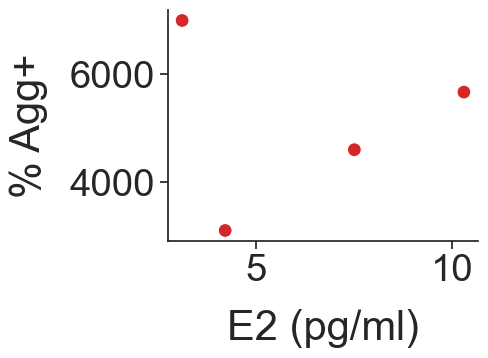

In [328]:
plt.subplots(figsize = (4,3))
ax = sns.scatterplot(data=virgin, x='max_estrogen_level(pg/ml)', y='switching probability_percent', 
                hue = 'estrous_stage', s = 100,palette = ['Tab:red'])
ax.set_ylabel('% Agg+',fontsize = 30, labelpad=15)
ax.set_xlabel('E2 (pg/ml)',fontsize = 30, labelpad=15)

ax.legend_.remove()
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_4/linked_figure_S4/E2_corr.pdf', dpi = 300,bbox_inches='tight', transparent=True)

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/845783764.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preg['switching probability_percent'] = preg['switching probability']
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/845783764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = 'estrous_stage', y = 'switching probability_percent', data = preg, palette = ['Tab:red', 'Tab:red'], alpha = 0.7)
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_51769/845783764.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
 

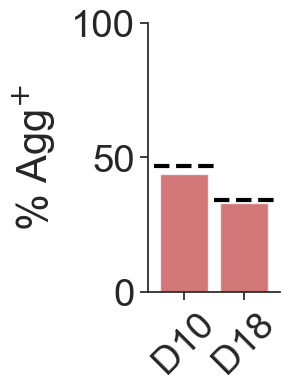

In [335]:
plt.subplots(figsize = (1.7,3.5))
sns.set(font_scale=2.5) 
sns.set_style("ticks")
preg['switching probability_percent'] = preg['switching probability']

ax = sns.barplot(x = 'estrous_stage', y = 'switching probability_percent', data = preg, palette = ['Tab:red', 'Tab:red'], alpha = 0.7)

i = 0
for stage in preg.estrous_stage.unique():
    v = preg[preg.estrous_stage == stage]['P/E* 10^-3'].values
    z = func(v[0], *popt)*100
    plt.hlines(y = z, xmin = i-0.5, xmax = i+ 0.5, linestyle = 'dashed', color = 'black', lw=3)
    i += 1
plt.xticks(rotation=45)
plt.yticks()
plt.ylabel(r'% Agg$^{+}$', labelpad=10) #$P_{S}$
plt.xlabel('')
ax.set_xticklabels( ('D10', 'D18'), rotation=45)
plt.ylim([0,100])
sns.despine(bottom=False)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_2/linked_figure2/preg_switching_prediction.pdf',
# dpi=600,bbox_inches='tight', transparent=True)

## Receptor expression in MPOA and Arcuate 

In [51]:
import pathlib
path = '/receptor_level/'

df1 = pd.read_csv(str(pathlib.Path().resolve()) + path+'df_166-3.csv')
df2 = pd.read_csv(str(pathlib.Path().resolve()) + path+'df_167-3.csv')

df = pd.concat([df1,df2])
average = df[['% Esr1','% PR']].mean()


df = df[df['Unnamed: 0'].isin(['MPO', 'MPN','PD', 'ADP','PS', 'ARH'])]

df = df.replace({'Unnamed: 0':{'ARH':'ARC'}})
df.loc['mean'] = df[df['Unnamed: 0'].isin(['MPO', 'MPN','PD', 'ADP','PS'])].iloc[:,1:].mean()
df = df.replace({'Unnamed: 0':{np.nan:'MPOA'}})

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/3993943115.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(x = 'Unnamed: 0',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/3993943115.py:6: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.barplot(x = 'Unnamed: 0',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/3993943115.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g2 =sns.barplot(x = 'Unnamed: 0',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/3993943115.py:26: UserWarning: 
The palette list has fewer values (1) than needed (2) and w

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure_2/linked_figure2/receptor_proportion.pdf'

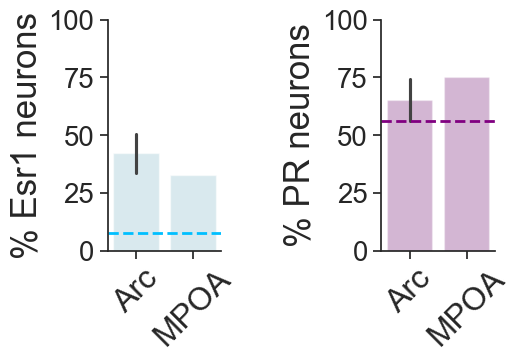

In [52]:
fig = plt.figure(figsize = (5,3))
sns.set(font_scale=1.8)
sns.set_style("ticks")
ax1 = fig.add_subplot(131)

g = sns.barplot(x = 'Unnamed: 0', 
            y = '% Esr1',
            data = df[df['Unnamed: 0'].isin(['MPOA', 'ARC'])],
            alpha=.5, 
            palette=["lightblue"])

g.axhline(average['% Esr1'], 
          color = 'deepskyblue',
          linewidth=2,
          linestyle = 'dashed')

plt.ylim([0,100])

ax1.set_ylabel('% Esr1 neurons',fontsize = 25)
sns.despine()
plt.xticks([0,1], ['Arc', 'MPOA'], rotation=45, fontsize = 23)
plt.xlabel('')

ax2 = plt.subplot(133)

g2 =sns.barplot(x = 'Unnamed: 0', 
            y = '% PR',
            data = df[df['Unnamed: 0'].isin(['MPOA', 'ARC'])],
            alpha=0.3, 
            palette=["purple"])

g2.axhline(average['% PR'], 
           color = 'purple',
           linewidth=2,
           linestyle = 'dashed')

plt.ylim([0,100])

ax2.set_ylabel('% PR neurons',fontsize = 25)

sns.despine()
plt.xticks([0,1], ['Arc', 'MPOA'], rotation=45, fontsize = 23)
plt.xlabel('')
plt.savefig('output_figures/receptor_proportion', dpi = 300)
plt.savefig('/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure_2/linked_figure2/receptor_proportion.pdf',dpi = 600,bbox_inches='tight', transparent=True)

# Pregnancy stage and NPS probability

initialize pregnancy stages and extract data

pre state analysis

In [53]:
data

,mice_ID,exp_cond,deprivation_duration,birth_date,estrous_stage,state_before,retrieval_before_latency,state_before_comment,1h_food_consumption_before,state_after,...,target_2_before,litter_size,target,target_after,target_after_latency,target_2_after,exp_time,prev_exp,exp_date,Unnamed: 26
0,JKAM3.1h,all_stressor_5h,404,20/07/2019,E,Parental-,NaN,NaN,NaN,Agg-,...,NaN,NaN,pup,NaN,NaN,NaN,1,NaN,09/11/2019,NaN
1,JKAM2.1e,all_stressor_5h,363,26/07/2019,M,Parental+,NaN,build a nest around the pups,NaN,Agg+,...,NaN,NaN,pup,NaN,NaN,NaN,1,NaN,10/11/2019,NaN
2,JKAM2.1d,all_stressor_5h,431,26/07/2019,D,Parental+,102.0,NaN,NaN,Agg+,...,NaN,NaN,pup,NaN,NaN,NaN,1,NaN,12/11/2019,NaN
3,JKAM2.1g,all_stressor_5h,450,26/07/2019,D,Parental+,33.0,NaN,NaN,Agg+,...,NaN,NaN,pup,NaN,NaN,NaN,1,NaN,12/11/2019,NaN
4,JKAM3.1j,all_stressor_5h,383,20/07/2019,P,Parental+,30.0,NaN,NaN,Agg-,...,NaN,NaN,pup,NaN,NaN,NaN,1,NaN,13/11/2019,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,BRAC5370.6e,food_deprivation,NaN,NaN,D,Parental+,NaN,build a nest around one pup,NaN,Agg-,...,NaN,NaN,openfield,NaN,NaN,NaN,1,NaN,22/07/2021,NaN
328,BRAC5539.5g,food_deprivation,NaN,NaN,D,Parental+,NaN,build a nest around both pups,NaN,Agg-,...,NaN,NaN,openfield,NaN,NaN,NaN,1,NaN,22/07/2021,NaN
329,BRAC5539.5h,food_deprivation,NaN,NaN,M,Parental-,NaN,NaN,NaN,Agg-,...,NaN,NaN,openfield,NaN,NaN,NaN,1,NaN,22/07/2021,NaN
330,BRAC5539.5i,food_deprivation,NaN,NaN,D,Parental-,NaN,NaN,NaN,Agg+,...,NaN,NaN,refeeding_2h,NaN,NaN,NaN,1,NaN,22/07/2021,NaN


In [54]:
preg_stages_pre = ['PD2', 'PD2_pre', 'PD10', 'PD18']
preg_stages = ['PD2','PD10', 'PD18']
preg_data = data[data.target.isin(preg_stages)]

In [55]:
preg_data_pre = data[data.target.isin(preg_stages_pre)]
preg_data_pre = preg_data_pre.replace('PD2_pre', 'PD2')
preg_data_pre_count = preg_data_pre.groupby(['target']).size().reset_index(name='count')
preg_data_pre = preg_data_pre.groupby(['state_before','target']).size().reset_index(name = 'n')
preg_data_pre = preg_data_pre.merge(preg_data_pre_count, how = 'outer', on = 'target')
preg_data_pre['percent'] = preg_data_pre['n'] / preg_data_pre['count']
preg_data_pre['target'] = pd.Categorical(preg_data_pre['target'], ['PD2', 'PD10', 'PD18'])

preg_data_pre = preg_data_pre.sort_values(by = ['target'])
print(preg_data_pre)

  state_before target  n  count  percent
4    Parental+    PD2  5      8    0.625
5    Parental-    PD2  3      8    0.375
0    Parental+   PD10  6      8    0.750
1    Parental-   PD10  2      8    0.250
2    Parental+   PD18  7      8    0.875
3    Parental-   PD18  1      8    0.125


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1378894850.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  preg_data_pre = preg_data_pre.replace('PD2_pre', 'PD2')


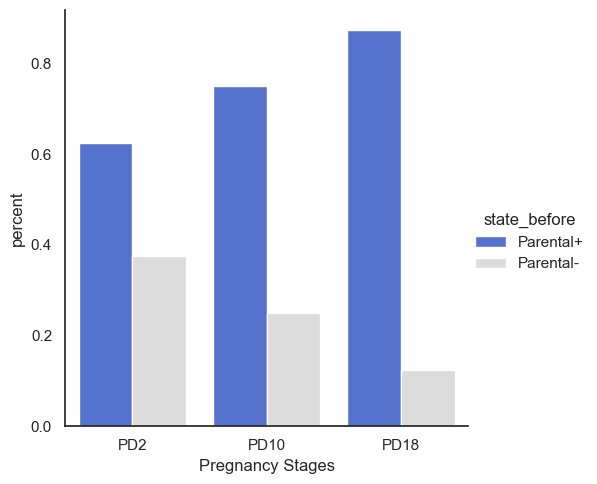

In [56]:
sns.set(rc={'figure.figsize':(7,5)})
sns.set_style("white")
g = sns.catplot(x = 'target', 
                y = 'percent', 
                hue = 'state_before', 
                kind = 'bar', 
                data = preg_data_pre,
                palette = ['royalblue', 'gainsboro'])
g.set(xlabel = 'Pregnancy Stages')

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1824354490.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(x = 'target',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1824354490.py:5: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  g = sns.catplot(x = 'target',


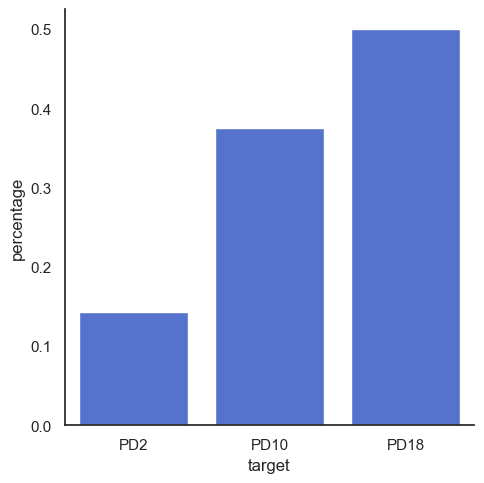

In [57]:
ret_per = preg_data.groupby('target')['retrieval_before_latency'].apply(lambda x: x.notnull().mean()).reset_index(name = 'percentage')

sns.set(rc={'figure.figsize':(5,5)})
sns.set_style("white")
g = sns.catplot(x = 'target', 
                y = 'percentage',
                kind = 'bar', 
                data = ret_per,
                order = preg_stages,
                palette = ['royalblue'])

post state analysis

In [58]:
preg_data_post_count = preg_data.groupby(['target']).size().reset_index(name='count')
preg_data_post = preg_data.groupby(['state_after','target']).size().reset_index(name = 'n')
preg_data_post = preg_data_post.merge(preg_data_post_count, how = 'outer', on = 'target')
preg_data_post['percent'] = preg_data_post['n'] / preg_data_post['count']
preg_data_post['target'] = pd.Categorical(preg_data_post['target'], ['PD2', 'PD10', 'PD18'])

preg_data_post = preg_data_post.sort_values(by = ['target'])
print(preg_data_post)

  state_after target  n  count   percent
4        Agg+    PD2  3      7  0.428571
5        Agg-    PD2  4      7  0.571429
0        Agg+   PD10  3      8  0.375000
1        Agg-   PD10  5      8  0.625000
2        Agg+   PD18  1      8  0.125000
3        Agg-   PD18  7      8  0.875000


In [59]:
preg_hor = pd.concat([hormone,preg])
preg_hor = preg_hor.set_index('stage')
preg_hor = preg_hor.loc[[ 'PD10', 'PD18']]

NameError: name 'preg' is not defined

NameError: name 'preg_hor' is not defined

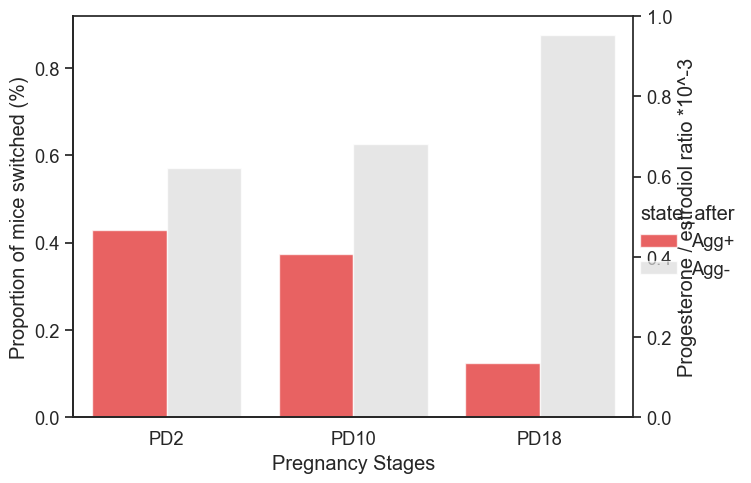

In [60]:
sns.set(font_scale=1.2)
sns.set_style("white")
g = sns.catplot(x = 'target', 
                y = 'percent', 
                hue = 'state_after', 
                kind = 'bar', 
                data = preg_data_post,
                palette = ['red', 'gainsboro'],
                aspect = 20/15, alpha = 0.7)
g.set(xlabel = 'Pregnancy Stages')

ax = plt.gca()
ax.set_ylabel('Proportion of mice switched (%)')
ax2 = ax.twinx()
ax2.set_ylabel('Progesterone / estrodiol ratio *10^-3')
ax2.plot([ 'PD10', 'PD18'], preg_hor['P/E* 10^-3'], color = 'r', linewidth = 2)

ax2.legend(loc='center right', bbox_to_anchor=(1.35, 0.5), ncol=1)
ax2.set_ylim([0,9])
preg_n = preg_data_post.sort_values(by = ['state_after'])
autolabel(g, preg_n['n'].tolist())
sns.despine(top = True, right = False)

In [67]:
preg_cond_ig = {}
preg_cond_parental = {}

preg_data = data[data.target.isin(['PD2', 'PD10', 'PD18'])]

for preg_stage in preg_stages:
    preg_stage_data = preg_data[preg_data['target'] == preg_stage]
    preg_cond_ig[preg_stage], _ = compute_conditional(preg_stage_data, 'Agg+','state_after', 'Parental-','state_before')
    preg_cond_parental[preg_stage], _ = compute_conditional(preg_stage_data, 'Agg+','state_after','Parental+','state_before')

print(preg_cond_ig)
print(preg_cond_parental)

{'PD2': 0.5, 'PD10': 1.0, 'PD18': 0.0}
{'PD2': 0.4, 'PD10': 0.16666666666666666, 'PD18': 0.14285714285714285}


# Receptor KO and NPS

In [61]:
from scipy.stats import binom
from poibin import PoiBin

def binomial_range(data, estrous_data):
    ps = []
    
    for i in data['estrous_stage'].unique():
        n = int(data[data['estrous_stage'] == i]['estrous_count'].iloc[0])
        p = estrous_data[i] *0.01
        p = [p] * n
        
        ps.extend(p)
    
    # produce and return a poisson binomial pmf based on list of means from estrous cycle stages
    pb = PoiBin(ps)
    x = np.arange(0, int(data['estrous_count'].sum()/2))
    dist = pb.cdf(x)
    pmf = pb.pmf(x)

    # get mean of the distibution
    mean = int(np.where(pmf == pmf.max())[0]) # most probable value
    std = np.sqrt(np.sum([i*j for i, j in zip([1-p for p in ps] ,ps)]))
    mean_t  = np.sum(ps) # mean of the distribution
    
    # get the 0.05 interval 
    lower = mean_t - 2* std
    #lower = np.where(dist > 0.05)[0][0] # using distribution
    
    # get the 0.95 confidence interval
    higher = mean_t + 2 * std
    #higher = np.where(dist < 0.95)[0][-1] # using distribution
    
    
    return lower, higher, mean, pb
       

In [62]:
KO_dat = pd.read_csv('../NPW_hormone/receptor_KO/receptorKO.csv')

viruses = ['EGFP-CRE', 'EGFP']
areas = ['MPOA', 'ARC']
receptors = ['PR', 'ESR']

KO_dat = KO_dat[(KO_dat.injection_site.isin(areas)) &
                (KO_dat.validation != 'invalid')&
                (KO_dat.state_after!= 'invalid')]

KO_count = KO_dat.groupby(['KO', 'injection_site', 'virus', 'state_after']).size().reset_index(name='count')
KO_n = KO_dat.groupby(['KO','injection_site', 'virus']).size().reset_index(name = 'n')
KO_count = KO_count[KO_count.virus == 'EGFP-CRE']
KO_n = KO_n[KO_n.virus == 'EGFP-CRE']

c_count = KO_dat.groupby(['injection_site', 'virus', 'state_after']).size().reset_index(name='count')
c_n = KO_dat.groupby(['injection_site', 'virus']).size().reset_index(name = 'n')
c_count = c_count[c_count.virus == 'EGFP']
c_n = c_n[c_n.virus == 'EGFP']

KO_n = pd.concat([KO_n,c_n])
KO_count = pd.concat([KO_count, c_count])

In [ ]:
# calculate predicted probability of switching based on the number of animals in different estrous cycle stages

KO_df = KO_n.merge(KO_count, how = 'outer', on = ['KO', 'injection_site', 'virus'])
KO_df['percent'] = KO_df['count'] / KO_df['n'] *100


KO_probability = KO_dat.groupby(['KO', 'injection_site', 'virus', 'estrous_stage']).size().reset_index(name = 'estrous_count')
KO_probability = KO_probability[KO_probability.virus == 'EGFP-CRE']
c_probability = KO_dat.groupby(['injection_site', 'virus', 'estrous_stage']).size().reset_index(name = 'estrous_count')
c_probability = c_probability[c_probability.virus == 'EGFP']
KO_probability = pd.concat([KO_probability, c_probability])

KO_probability = KO_probability.merge(KO_df, how = 'outer', on = ['KO', 'injection_site', 'virus'])


for KO in receptors:
    for area in areas:
        for virus in viruses:

            
            if virus == 'EGFP-CRE':
                cond = ((KO_probability.injection_site == area) &
                            (KO_probability.KO == KO)&
                            (KO_probability.virus == virus))
            
                KO_est = KO_probability[cond]
                    
                    
            else:
                cond = ((KO_probability.injection_site == area) &
                            (KO_probability.virus == virus))
                
                KO_est = KO_probability[cond]
           
            if KO_est.empty:
                continue
            
            else:
               
                # input data to the poisson binomial distribution
                lower, higher, mean, pb = binomial_range(KO_est, estrous_data)

                KO_probability.loc[cond, 'lower'] = lower
                KO_probability.loc[cond, 'higher'] = higher
                KO_probability.loc[cond, 'mean'] = mean
                p_right = pb.pval(KO_probability[cond]['count'].iloc[0])
                p_left = 1 - p_right
                KO_probability.loc[cond, 'pvalue'] = min(p_right, p_left)


KO_probability.pop('estrous_stage')
KO_probability.pop('estrous_count')
KO_probability = KO_probability.drop_duplicates()


KO_probability['mean'] = KO_probability['mean'] / KO_probability['n'] *100
KO_probability['lower'] = KO_probability['lower'] / KO_probability['n'] *100
KO_probability['higher'] = KO_probability['higher'] / KO_probability['n'] *100

print(KO_probability)

     KO injection_site     virus   n state_after  count     percent  \
0   ESR            ARC  EGFP-CRE  10        Agg+      5   50.000000   
1   ESR            ARC  EGFP-CRE  10        Agg-      5   50.000000   
8   ESR           MPOA  EGFP-CRE  10        Agg+     10  100.000000   
12   PR            ARC  EGFP-CRE  11        Agg+      7   63.636364   
13   PR            ARC  EGFP-CRE  11        Agg-      4   36.363636   
20   PR           MPOA  EGFP-CRE  13        Agg+      3   23.076923   
21   PR           MPOA  EGFP-CRE  13        Agg-     10   76.923077   
28  NaN           MPOA      EGFP  10        Agg+      7   70.000000   
29  NaN           MPOA      EGFP  10        Agg-      3   30.000000   

        lower     higher       mean    pvalue  
0   23.550870  83.252354  50.000000  0.284795  
1   23.550870  83.252354  50.000000  0.284795  
8   17.139915  77.897543  40.000000  0.000390  
12  25.509241  84.212729  54.545455  0.390756  
13  25.509241  84.212729  54.545455  0.390756  
2

40.0
53.84615384615385


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1360044495.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(x = 'KO',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1360044495.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Esr1', 'PR'], rotation=45)


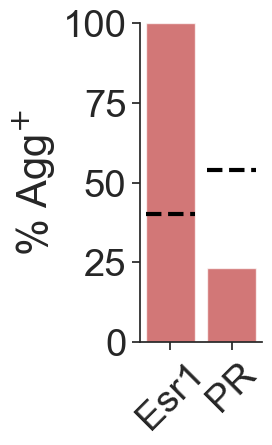

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1360044495.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(x = 'virus',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1360044495.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['ctrl'], rotation=45)


60.0


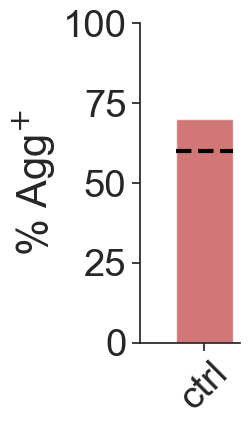

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1360044495.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(x = 'KO',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1360044495.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Esr1', 'PR'], rotation=45)


50.0
54.54545454545454


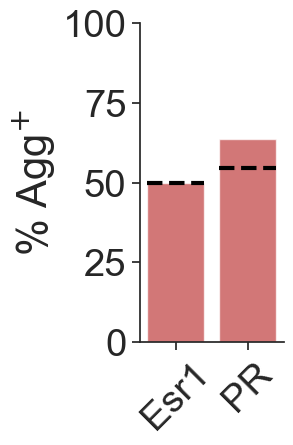

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1360044495.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(x = 'virus',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1360044495.py:36: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.catplot(x = 'virus',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1360044495.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['ctrl'], rotation=45)


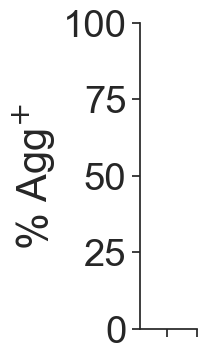

In [64]:
sns.set(font_scale=2.5)  
sns.set_style("ticks")

conds = ['EGFP-CRE', 'EGFP']

for area in areas:
    
    for cond in conds:
    
        KO = KO_probability[(KO_probability.injection_site == area)&
                            (KO_probability.virus == cond)]
        


        KO = KO[KO.state_after == 'Agg+']
        
        
        try:
        
            if cond == 'EGFP-CRE':  


                g = sns.catplot(x = 'KO',
                                y = 'percent', 
                                kind = 'bar', 
                                data = KO,
                                palette = ['Tab:red', 'Tab:red'], aspect = 10/15,
                                alpha = 0.7)
                plt.xlim(-0.5)
                ax = plt.gca()
                ax.set_xticklabels(['Esr1', 'PR'], rotation=45)

            else:


                g = sns.catplot(x = 'virus',
                                y = 'percent', 
                                kind = 'bar', 
                                data = KO,
                                palette = ['Tab:red'], aspect = 8.7/15,
                                alpha = 0.7)
                plt.xlim(-0.9)
                ax = plt.gca()
                ax.set_xticklabels(['ctrl'], rotation=45)

#             sns.set(rc={'figure.figsize':(5,1)})
            sns.set(font_scale=2.5)  
            sns.set_style("ticks")
            
            plt.ylim([0,100])
#             autolabel(g, KO['n'].tolist())
            ax = plt.gca()
            ax.set_ylabel(r'% Agg$^{+}$')
            
            sns.despine(trim=False, bottom=False)
#             ax.tick_params(bottom=False)

            # plot predicted switching probability based on estrous cycle the expriment mice are in
            xs = []

            for patch in ax.patches:

                width = patch.get_width()
                xs.append(patch.get_x())


            i = 0
            for x in xs:
                x_plot = np.linspace(x, x + width, 100)
                line = KO['mean'].iloc[i]
                y_plot = np.linspace(line,line,100)
                print(line)
               
                i = i +1
                plt.plot(x_plot,y_plot, linestyle = 'dashed', linewidth=3, color='black', 
                         label = 'Estrous stages\npredicted switching')

            g.set(xlabel = None) # area
#             print(KO)

#             plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_2/linked_figure2/' 
#                         + area + '_'+ cond + '_KO.pdf', dpi=300,bbox_inches='tight')
            plt.savefig('output_figures/' + area + '_'+ cond + '_KO.png', dpi=300,bbox_inches='tight')
            plt.show()
            
        except ValueError:
            pass

# HCN block cannulation experiment (preliminary)

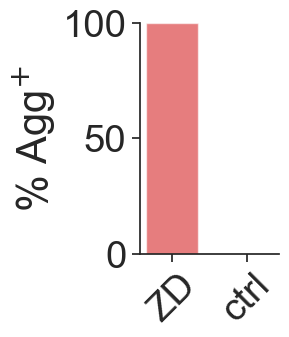

In [65]:
sns.set(font_scale=2.5)
sns.set_style("ticks")

estrous_data = {'ZD': 100, 'ctrl': 0}

fig, ax = plt.subplots(figsize=(1.8, 3))

# Create the bar plot
bars = plt.bar(range(len(estrous_data)), list(estrous_data.values()),
               tick_label=list(estrous_data.keys()), align='center',
               color='tab:red', width=0.7, alpha=0.6)

plt.xlabel('')
plt.ylabel(r'% Agg$^{+}$')
ax.set_xticklabels( ('ZD', 'ctrl'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 100)
sns.despine(bottom=False, trim=False)

# plt.savefig('/Users/kohlj/Dropbox (Personal)/Science/presentations_courses_travel/FENS_2024/talk/figures/HCN_cannulation.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

# Food intake Analysis

compare baseline, Agg+ and Agg- food intake and run statistics

In [112]:
# agg_cond_data_first_clean = agg_cond_data_first.dropna(subset=['1h_food_consumption_before'])
# cleaned_df = agg_cond_data_first_clean

In [113]:
food_intake = {}
food_intake['Pre'] = agg_cond_data_first['1h_food_consumption_before'].dropna().tolist()
food_intake['Agg+'] = agg_cond_data_first[agg_cond_data_first['state_after'] == 'Agg+']['1h_food_consumption_after'].dropna().tolist()
food_intake['Agg-'] = agg_cond_data_first[agg_cond_data_first['state_after'] == 'Agg-']['1h_food_consumption_after'].dropna().tolist()
food_intake['pup_absent'] = data[data['target'] == 'pup_absent']['1h_food_consumption_after'].dropna().tolist()
food_df = pd.concat([pd.DataFrame(food_intake[key], columns = [key]) for key in food_intake.keys()], axis = 1)
food_df = food_df.melt(var_name='state', value_name='food_consumption').dropna()
plot_df = food_df.copy()
plot_df.loc[plot_df['state'].isin(['Agg+', 'Agg-']), 'state'] = 'Post'
plot_df = plot_df[plot_df.state.isin(['Pre', 'Post'])]


In [114]:
stats.ttest_ind(plot_df[plot_df['state'] == 'Pre']['food_consumption'],
                plot_df[plot_df['state'] == 'Post']['food_consumption'])

Ttest_indResult(statistic=-16.439980974270895, pvalue=3.479778942199893e-30)

plot food intake of baseline and that of Agg+ and Agg- mice after the state-changing period

In [69]:
state_counts = plot_df['state'].value_counts()
print(state_counts)

state
Post    62
Pre     40
Name: count, dtype: int64


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/3162475156.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.stripplot(x = 'state', y = 'food_consumption', data = plot_df, color = 'black',  marker='o', size=7, linewidth=1, edgecolor='gray',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/3162475156.py:5: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  ax = sns.stripplot(x = 'state', y = 'food_consumption', data = plot_df, color = 'black',  marker='o', size=7, linewidth=1, edgecolor='gray',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/3162475156.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for 

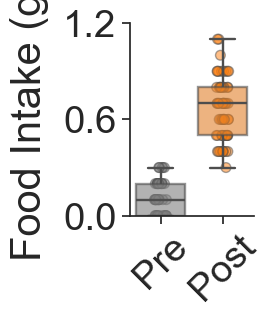

In [70]:
sns.set(rc={"figure.figsize": (1.6, 2.5)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.stripplot(x = 'state', y = 'food_consumption', data = plot_df, color = 'black',  marker='o', size=7, linewidth=1, edgecolor='gray',
                  alpha=0.5, zorder=1, jitter = True, palette = ['gray', 'Tab:orange'])
ax = sns.boxplot(x = 'state', y = 'food_consumption',data = plot_df,  palette = ['gray', 'Tab:orange'], linewidth=1.7, 
                 showfliers=False, boxprops=dict(alpha=.6))

ax.set_ylabel('Food Intake (g)', labelpad=10)  
ax.set(xlabel = '')

plt.xticks(rotation=45)
plt.ylim(0, 1.2)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/food_prepost.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

compare baseline, post phase Agg+, Parental+ and Parental- mice food intake and run statistics

In [71]:
food_intake_state_plot = {}
food_intake_state = {}

food_intake_state_plot['Agg+'] = agg_cond_data_first[agg_cond_data_first['state_after'] == 'Agg+']['1h_food_consumption_after']
food_intake_state_plot['Parental+'] = agg_cond_data_first[agg_cond_data_first['parental_state_after'] == 'Parental+']['1h_food_consumption_after']
food_intake_state_plot['Parental-'] = agg_cond_data_first[agg_cond_data_first['parental_state_after'] == 'Parental-']['1h_food_consumption_after']
food_intake_state['Agg+'] = food_intake_state_plot['Agg+'].dropna().tolist()
food_intake_state['Parental+'] = food_intake_state_plot['Parental+'].dropna().tolist()
food_intake_state['Parental-'] = food_intake_state_plot['Parental-'].dropna().tolist()


stats1, p1_s = stats.ttest_ind(food_intake_state['Agg+'],
                                food_intake_state['Parental+'],
                                equal_var = False)
stats2, p2_s = stats.ttest_ind(food_intake_state['Agg+'],
                                food_intake_state['Parental-'],
                                equal_var = False)
stats3, p3_s = stats.ttest_ind(food_intake_state['Parental+'],
                                food_intake_state['Parental-'],
                             equal_var = False)
print({key: len(value) for key, value in food_intake_state.items()})
print(p1_s, p2_s, p3_s)

{'Agg+': 32, 'Parental+': 19, 'Parental-': 10}
0.0024303631448219596 0.0029354400434227785 0.5189814241789504


visualise food intake of baseline and that of Agg+, Parental+ and Parental- mice after the state-changing period

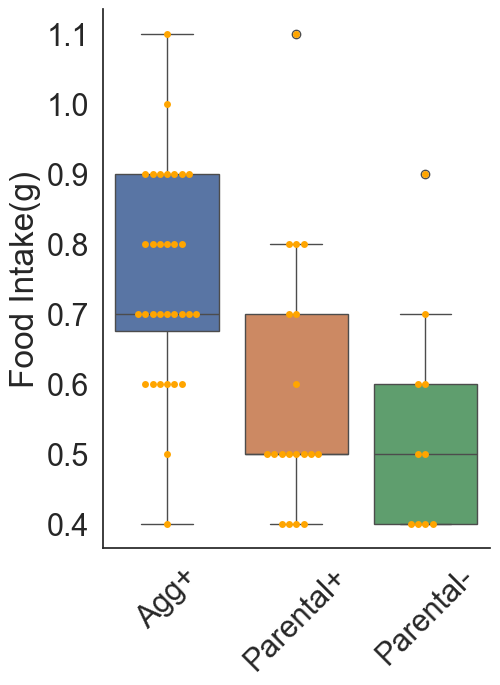

In [72]:
food_intake_state_plot = pd.DataFrame.from_dict(food_intake_state_plot)

sns.set(rc={'figure.figsize':(5, 7)})
sns.set(font_scale=2)
sns.set_style("white")
ax = sns.boxplot(data = food_intake_state_plot)
sns.despine()
for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .3))
sns.swarmplot(data = food_intake_state_plot, color = 'orange')
ax.set(ylabel = 'Food Intake(g)')
plt.xticks(rotation=45)
ax.grid(False)

invesgate how _food cycle affect the food intake before and after going through the state_changing period

In [73]:
# calculate the number of animals in each estrous cycle stage
agg_cond_data_first[agg_cond_data_first['1h_food_consumption_after'].notnull()]['estrous_stage'].value_counts()

estrous_stage
D    20
M    17
P    14
E     9
Name: count, dtype: int64

In [188]:
response_var = '1h_food_consumption_before'
formula = f'Q("{response_var}") ~ estrous_stage'
model = smf.ols(formula, data = agg_cond_data_first).fit()
anova_table = sm.stats.anova_lm(model, typ = 2)
print(anova_table)

                 sum_sq    df         F    PR(>F)
estrous_stage  0.026353   3.0  0.867787  0.467263
Residual       0.344173  34.0       NaN       NaN


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/684066784.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_cond_data_first.estrous_stage = pd.Categorical(agg_cond_data_first['estrous_stage'], ['P', 'E', 'M', 'D'])
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/684066784.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x = 'estrous_stage',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/684066784.py:8: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.swarmp

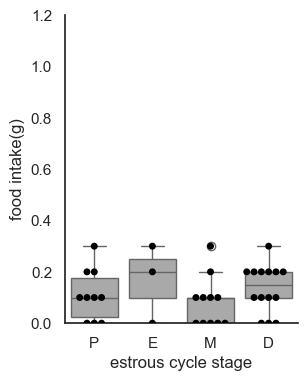

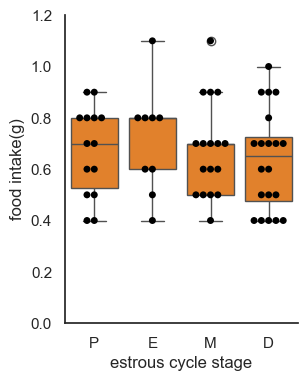

In [74]:
agg_cond_data_first.estrous_stage = pd.Categorical(agg_cond_data_first['estrous_stage'], ['P', 'E', 'M', 'D'])
agg_cond_data_first.sort_values(by = 'estrous_stage')

sns.set(rc={'figure.figsize':(3,4)})
sns.set_style("white")

plt.subplots()
sns.swarmplot(x = 'estrous_stage',
                y =  '1h_food_consumption_before',
                data = agg_cond_data_first,
                dodge = False, palette = [ 'black'])

sns.boxplot(x = 'estrous_stage',
                y =  '1h_food_consumption_before',
                data = agg_cond_data_first,
                dodge = False, palette = ['darkgray'])

plt.xlabel('estrous cycle stage')
plt.ylabel('food intake(g)')
plt.ylim([0,1.2])
sns.despine()
plt.savefig('output_figures/before_estrous_food.jpg', dpi = 300, bbox_inches = 'tight')


plt.subplots()
sns.swarmplot(x = 'estrous_stage',
                y =  '1h_food_consumption_after',
                data = agg_cond_data_first,
                dodge = False, palette = [ 'black'])

sns.boxplot(x = 'estrous_stage',
                y =  '1h_food_consumption_after',
                data = agg_cond_data_first,
                dodge = False,  palette = ['Tab:orange'])

plt.ylim([0,1.2])

plt.xlabel('estrous cycle stage')
plt.ylabel('food intake(g)')
sns.despine()
plt.savefig('output_figures/after_estrous_food.jpg', dpi = 300, bbox_inches = 'tight')

plotting correlation between food intake and attack latency

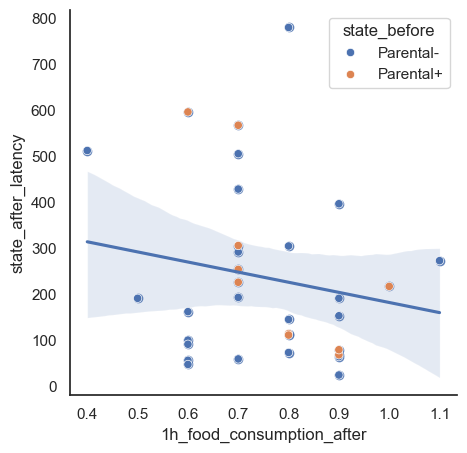

In [75]:
sns.set(rc={'figure.figsize':(5,5)})
sns.set_style("white")


sns.regplot(x = '1h_food_consumption_after',
            y = 'state_after_latency',
            data = agg_cond_data_first)

sns. scatterplot(data = agg_cond_data_first, 
                 x = '1h_food_consumption_after',
                 y = 'state_after_latency',
                hue = 'state_before')
sns.despine()

plot regression line fit for relation between attack latency and food consumption

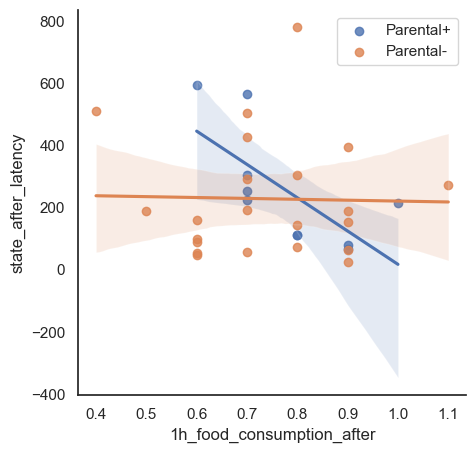

In [76]:
sns.set(rc={'figure.figsize':(5,5)})
sns.set_style("white")

pos = sns.regplot(x = '1h_food_consumption_after',
            y = 'state_after_latency',
            data = agg_cond_data_first[agg_cond_data_first['state_before'] == 'Parental+'], label = 'Parental+')

neg = sns.regplot(x = '1h_food_consumption_after',
            y = 'state_after_latency',
            data = agg_cond_data_first[agg_cond_data_first['state_before'] == 'Parental-'], label = 'Parental-')

plt.legend()
sns.despine()

Investigate food consumption diff (new)

In [156]:
food_df = pd.read_csv('food_consumption.csv')
food_df = food_df[food_df.status == 'use']

model = smf.ols('net_food ~ Behaviour', data = food_df[food_df.Behaviour!='nopup']).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table)


             sum_sq    df          F        PR(>F)
Behaviour  3.299249   2.0  117.50878  6.245710e-18
Residual   0.589609  42.0        NaN           NaN


In [79]:
# mouse numbers
mouse_count = food_df.groupby('Behaviour')['Mice_ID'].nunique().reset_index()
mouse_count

,Behaviour,Mice_ID
0,Agg+,7
1,Agg-,6
2,baseline,30
3,nopup,28


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/148515109.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.stripplot(x='Behaviour', y='net_food', data = food_df, order = ['baseline','Agg+', 'Agg-'], jitter=True, dodge=False,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/148515109.py:5: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  g = sns.stripplot(x='Behaviour', y='net_food', data = food_df, order = ['baseline','Agg+', 'Agg-'], jitter=True, dodge=False,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/148515109.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxpl

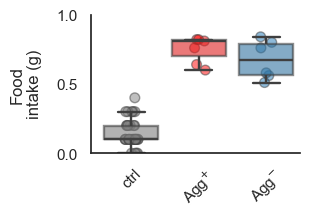

In [80]:
plt.subplots(figsize= (2.7,1.8))
sns.set(font_scale=2.7) 
sns.set_style("ticks")

g = sns.stripplot(x='Behaviour', y='net_food', data = food_df, order = ['baseline','Agg+', 'Agg-'], jitter=True, dodge=False, 
              marker='o', size=7, linewidth=1, edgecolor='gray', palette=['gray','red', 'Tab:blue'], alpha=0.5, zorder=1)
g = sns.boxplot(x = 'Behaviour', y = 'net_food', data = food_df, order = ['baseline', 'Agg+', 'Agg-'], palette = ['gray', 'red', 'Tab:blue'], 
                 linewidth=1.7, showfliers=False,boxprops=dict(alpha=.6))

plt.ylabel('Food\nintake (g)', labelpad=10)
plt.xlabel('')
g.yaxis.set_major_locator(plt.MaxNLocator(2))
g.set_xticklabels(('ctrl', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

plt.ylim(0,1)
plt.xlim(-0.6)
sns.despine(trim=False, bottom=False)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/food_consumption.pdf',
#             dpi=600,bbox_inches='tight', transparent=True)

# Target Specificity Analysis

### Predation Test 

Data extraction and reindexing

In [81]:
cricket_df = agg_cond_data_first[agg_cond_data_first['target'] == 'cricket']

cricket_data_before = cricket_df.groupby(['state_after','target_before']).size().reset_index(name = 'n')
cricket_data_count = cricket_df.groupby(['state_after']).size().reset_index(name='count')
cricket_data_before = cricket_data_before.merge(cricket_data_count, how = 'outer', on = 'state_after')
cricket_data_after = cricket_df.groupby(['state_after','target_after']).size().reset_index(name='n')
cricket_data_after = cricket_data_after.merge(cricket_data_count, how = 'outer', on = 'state_after')

cricket_data_before = cricket_data_before.rename(columns = {'target_before': 'target'})
cricket_data_after = cricket_data_after.rename(columns = {'target_after': 'target'})
cricket_data = pd.concat([cricket_data_before, cricket_data_after], keys = ['Pre', 'Post'])
cricket_data.reset_index(inplace = True)
cricket_data['percent'] = (cricket_data['n'] / cricket_data['count']) * 100

agg_plus_cricket = cricket_data[cricket_data['state_after'] == 'Agg+'].reset_index()
agg_minus_cricket = cricket_data[cricket_data['state_after'] == 'Agg-'].reset_index()

In [121]:
condition_df = pd.crosstab(cricket_df['state_after'], cricket_df['target_after']).reset_index()
stats.fisher_exact(condition_df.iloc[:,1:])

SignificanceResult(statistic=3.3333333333333335, pvalue=0.5879120879120879)

In [83]:
condition_df = pd.crosstab(cricket_df['state_after'], cricket_df['target_after'], normalize='index').reset_index()
condition_df = condition_df.melt(id_vars = 'state_after', value_name = 'percent')
condition_df['percent'] = condition_df['percent'] * 100
condition_df

,state_after,target_after,percent
0,Agg+,Hunt+,40.000000
1,Agg-,Hunt+,16.666667
2,Agg+,Hunt-,60.000000
3,Agg-,Hunt-,83.333333


In [203]:
stats_df =pd.crosstab(cricket_df['state_after'], cricket_df['target_after']).reset_index()
stats.fisher_exact(stats_df.iloc[:,1:])

SignificanceResult(statistic=3.3333333333333335, pvalue=0.5879120879120879)

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1988572727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g1 = sns.catplot(x = 'state_after',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1988572727.py:3: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g1 = sns.catplot(x = 'state_after',


FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure_1/linked_figure_S1/circket_cond_agg.pdf'

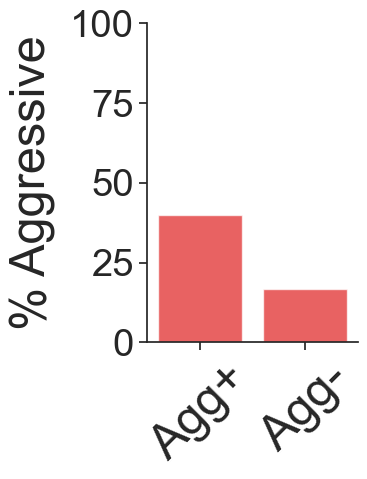

In [84]:
sns.set(font_scale=2.5) 
sns.set_style("ticks")
g1 = sns.catplot(x = 'state_after',
            y = 'percent', 
            data = condition_df[condition_df['target_after'] == 'Hunt+'],
            kind = 'bar', 
            palette=['red'],
            alpha = 0.7,
            aspect=0.8)
plt.ylim([0,100])
plt.ylabel('% Aggressive',fontsize = 35,labelpad=10)
plt.xlabel('')
plt.xticks(fontsize = 35, rotation=45)
plt.savefig('/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure_1/linked_figure_S1/circket_cond_agg.pdf',
            dpi=600,bbox_inches='tight', transparent=True)

calculate statistics of pre and post phase cricket hunt probabilities

In [122]:
plus_odds, plus_p = stats.fisher_exact([[agg_plus_cricket.n[0], agg_plus_cricket.n[1]],
                                        [agg_plus_cricket.n[2], agg_plus_cricket.n[3]]])

minus_odds, minus_p = stats.fisher_exact([[agg_minus_cricket.n[0], agg_minus_cricket.n[1]],
                                        [agg_minus_cricket.n[2], agg_minus_cricket.n[3]]])

print(plus_p, minus_p)

0.6284829721362228 1.0


data visualisation

In [119]:
cricket_data_filtered = cricket_data[cricket_data['target'] == 'Hunt+']
cricket_data_avg = cricket_data_filtered.groupby(['level_0', 'target']).mean().reset_index()
order = cricket_data_avg['level_0'].unique()[::-1]  # Reverse the order

sns.set(font_scale=2.5) 
sns.set_style("ticks")

g1 = sns.catplot(x = 'level_0',
            y = 'percent', 
            data = cricket_data_avg,
            hue = 'target',
            kind = 'bar', 
            palette=['red'],
            alpha = 0.7, aspect=0.8, order=order)

g1.set(xlabel = None)
g1.set(ylabel = '% Aggressive')
plt.ylim([0,100])
g1._legend.remove()

g1._legend.set_title(None)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/cricket.pdf',
            dpi = 600, bbox_inches='tight',transparent=True)

TypeError: agg function failed [how->mean,dtype->object]

### Intruder test
<br>
data extraction and reindexing

In [123]:
intruder_data = agg_cond_data_first[agg_cond_data_first['target'] == 'intruder']
intruder_data_tb = intruder_data.groupby(['state_after', 'target_before']).size().reset_index(name='n')
intruder_data_ta = intruder_data.groupby(['state_after', 'target_after']).size().reset_index(name='n')
intruder_data_tb = intruder_data_tb.rename(columns = {'target_before': 'target'})
intruder_data_ta = intruder_data_ta.rename(columns = {'target_after': 'target'})
intruder_data_t = pd.concat([intruder_data_tb, intruder_data_ta], keys = ['Pre', 'Post'])
intruder_data_t.reset_index(inplace = True)
ls = intruder_data_t.columns.tolist()

Agg_t = pd.DataFrame([['Pre', '0', 'Agg+', 'Agg+', 0],
                     ['Post', '1', 'Agg+', 'Agg+', 0],
                     ['Pre', '0', 'Agg-', 'Agg+', 0],
                     ['Post', '1', 'Agg-', 'Agg+', 0]],
                     columns = ls)

intruder_data_t = pd.concat([intruder_data_t, Agg_t])

intruder_data_t2b = intruder_data.groupby(['state_after', 'target_2_before']).size().reset_index(name='n')
intruder_data_t2a = intruder_data.groupby(['state_after', 'target_2_after']).size().reset_index(name='n')
intruder_data_t2b = intruder_data_t2b.rename(columns = {'target_2_before': 'target'})
intruder_data_t2a = intruder_data_t2a.rename(columns = {'target_2_after': 'target'})
intruder_data_t2 = pd.concat([intruder_data_t2b, intruder_data_t2a], keys = ['Pre', 'Post'])
intruder_data_t2.reset_index(inplace = True)
Agg_t2 = pd.DataFrame([['Pre', '0', 'Agg+', 'Agg+', 0],
                     ['Post', '1', 'Agg+', 'Agg+', 0],
                     ['Pre', '0', 'Agg-', 'Agg+', 0],
                     ['Post', '1', 'Agg-', 'Agg+', 0]],
                     columns = ls)
intruder_data_t2 = pd.concat([intruder_data_t2, Agg_t2])


intruder_data_count = intruder_data.groupby(['state_after']).size().reset_index(name='count')
intruder_data_t = intruder_data_t.merge(intruder_data_count, how = 'outer', on = 'state_after')
intruder_data_t2 = intruder_data_t2.merge(intruder_data_count, how = 'outer', on = 'state_after')

intruder_data_t['percent'] = (intruder_data_t['n'] / intruder_data_t['count']) * 100
intruder_data_t2['percent'] = (intruder_data_t2['n'] / intruder_data_t2['count']) * 100

In [127]:
intruder_data_t2

,level_0,level_1,state_after,target,n,count,percent
0,Pre,0,Agg+,Agg-,10,10,100.0
1,Post,0,Agg+,Agg-,10,10,100.0
2,Pre,0,Agg+,Agg+,0,10,0.0
3,Post,1,Agg+,Agg+,0,10,0.0
4,Pre,1,Agg-,Agg-,6,6,100.0
5,Post,1,Agg-,Agg-,6,6,100.0
6,Pre,0,Agg-,Agg+,0,6,0.0
7,Post,1,Agg-,Agg+,0,6,0.0


intruder test data visualization (male and female intruders)

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/female intruder.pdf'

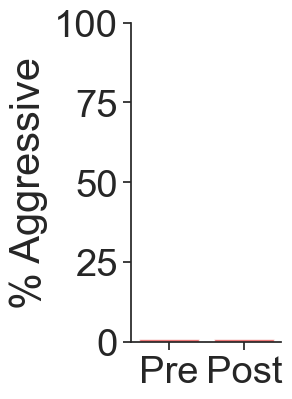

In [124]:
sns.set(font_scale=2.5) 
sns.set_style("ticks")

intruder_data_t = intruder_data_t.rename(columns={'state_after': 'Post state'})
intruder_data_t = intruder_data_t[(intruder_data_t['Post state'] == 'Agg+')&
                                  (intruder_data_t.target == 'Agg+')]

# add small const. value to 0 values so that columns become visible
small_value = 1
intruder_data_t.loc[intruder_data_t['percent'] == 0, 'percent'] += small_value

g1 = sns.catplot(x = 'level_0',
            y = 'percent', 
            hue = 'target',
            data = intruder_data_t,
            kind = 'bar', 
            palette=['red'],
            alpha = 0.7, aspect=0.8)

# autolabel(g1, intruder_data_t['count'].tolist())
g1.set(xlabel = None)
g1.set(ylabel = '% Aggressive')
plt.ylim([0,100])
g1._legend.remove()

g1._legend.set_title(None)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/female intruder.pdf',
            dpi = 600, bbox_inches='tight',transparent=True)

intruder_data_t2 = intruder_data_t2.rename(columns={'state_after': 'Post state'})
intruder_data_t2 = intruder_data_t2.rename(columns={'state_after': 'Post state'})
intruder_data_t2 = intruder_data_t2[(intruder_data_t2['Post state'] == 'Agg+')&
                                   (intruder_data_t2.target == 'Agg+')]

# add small const. value to 0 values so that columns become visible
intruder_data_t2.loc[intruder_data_t2['percent'] == 0, 'percent'] += small_value

g2 = sns.catplot(x = 'level_0',
            y = 'percent', 
            hue = 'target',
            data = intruder_data_t2,
            kind = 'bar', 
            palette=['red'],
            alpha = 0.7, aspect=0.8)

g2._legend.set_title(None)
g2._legend.remove()
# autolabel(g2, intruder_data_t2['count'].tolist()) # display number of mice in each group
g2.set(xlabel = None)
plt.ylim([0,100])
g2.set(ylabel = '% Aggressive')
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/male intruder.pdf',
            dpi = 600, bbox_inches='tight',transparent=True)

# Elevated Plus Maze

extract and clean maze data from EthoVision output

In [89]:
maze_data = pd.read_excel('Statistics-plus_maze_2601.xlsx', engine = 'openpyxl')
ID = ['BRAC5018.4d', 'BRAC5018.4e', 'BRAC5048.5c', 'BRAC5048.5d',
      'BRAC5048.5e', 'BRAC5081.3c', 'BRAC5081.3d', 'BRAC5081.3e',
      'BRAC5195.3c', 'BRAC5195.3d', 'BRAC5195.3e', 'BRAC5204.2h',
      'BRAC5081.3c', 'BRAC5018.4d', 'BRAC5018.4e', 'BRAC5048.5c',
      'BRAC5048.5d', 'BRAC5048.5e', 'BRAC5081.3d', 'BRAC5081.3e',
      'BRAC5195.3c', 'BRAC5195.3d', 'BRAC5195.3e', 'BRAC5204.2h',
      'BRAC5204.2i', 'BRAC5204.2j', 'BRAC5266.1f', 'BRAC5266.1g']

maze_data_0 = maze_data[maze_data['result'].isin(['Result 1', 'Result 1 (2)'])]
maze_data = maze_data.loc[maze_data['result'].isin(['Pre', 'Post'])]
maze_data['mice_ID'] = ID
maze_data_merge = pd.merge(maze_data, agg_cond_data_first, how = 'left', on = 'mice_ID')
maze_data_merge_t = pd.merge(maze_data_merge, maze_data_0, how = 'left', on = 'trial')

calculate statistical difference between Agg+ and Agg- in terms of anxiety related parameters

In [90]:
maze_data_merge['ratio'] = maze_data_merge['In open arms open_arm / center-point Cumulative Duration s'].div(
                           maze_data_merge['In closed arms closed_arm / center-point Cumulative Duration s'])

maze_control = maze_data_merge[maze_data_merge['result'] == 'Pre']
maze_test = maze_data_merge[maze_data_merge['result'] == 'Post']

stats_b, p_b = stats.ttest_ind(maze_control[maze_control['state_after'] == 'Agg+']['ratio'],
                               maze_control[maze_control['state_after'] == 'Agg-']['ratio'],
                               equal_var = False)

stats_a, p_a = stats.ttest_ind(maze_test[maze_test['state_after'] == 'Agg+']['ratio'],
                               maze_test[maze_test['state_after'] == 'Agg-']['ratio'],
                               equal_var = False)

stats_plus, p_plus = stats.ttest_ind(maze_control[maze_control['state_after'] == 'Agg+']['ratio'],
                               maze_test[maze_test['state_after'] == 'Agg+']['ratio'],
                               equal_var = False)

stats_minus, p_minus = stats.ttest_ind(maze_control[maze_control['state_after'] == 'Agg-']['ratio'],
                               maze_test[maze_test['state_after'] == 'Agg-']['ratio'],
                               equal_var = False)
print(p_b, p_a, p_plus, p_minus)

0.8264208087067954 0.7220669520605643 0.42629904467606594 0.16138638571120453


In [133]:
# two-way ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

maze_data_merge['state_after'] = pd.Categorical(maze_data_merge['state_after'], ['Agg+', 'Agg-'])
maze_data_merge['result'] = pd.Categorical(maze_data_merge['result'], ['Pre', 'Post'])

model = ols('ratio ~ C(state_after) + C(result) + C(state_after):C(result) ', data = maze_data_merge).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                             sum_sq    df         F    PR(>F)
C(state_after)             0.081362   1.0  0.098517  0.756328
C(result)                  2.231250   1.0  2.701704  0.113279
C(state_after):C(result)   0.027061   1.0  0.032766  0.857876
Residual                  19.820826  24.0       NaN       NaN


calculate statistical difference between spontaneous Parental+ and Parental- in terms of anxiety related parameters

In [91]:
stats_b_p, p_b_p = stats.ttest_ind(maze_control[maze_control['state_before'] == 'Parental+']['ratio'],
                               maze_control[maze_control['state_before'] == 'Parental-']['ratio'],
                               equal_var = False)

stats_a_p, p_a_p = stats.ttest_ind(maze_test[maze_test['state_before'] == 'Parental+']['ratio'],
                               maze_test[maze_test['state_before'] == 'Parental-']['ratio'],
                               equal_var = False)

stats_p, p_p = stats.ttest_ind(maze_control[maze_control['state_before'] == 'Parental+']['ratio'],
                               maze_test[maze_test['state_before'] == 'Parental+']['ratio'],
                               equal_var = False)

print(p_b_p, p_a_p, p_p)

0.12388124917081016 0.25462453336622937 0.27666604506360143


visualization of various elevated_pluz_maze related parameters between Agg+ and Agg- groups

IndexError: list index out of range

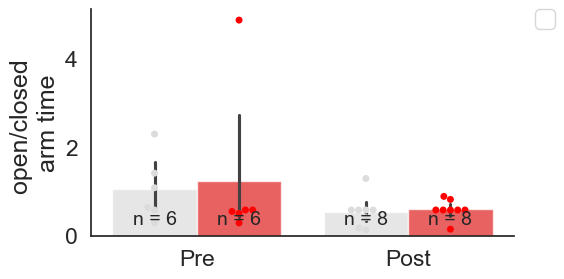

In [92]:
fig = plt.figure(figsize = (12,10))
n = [6, 8, 6, 8]
sns.set(font_scale=1.5)
sns.set_style("white")
ax1 = fig.add_subplot(321)
category_plotting_2('result','ratio','state_after',maze_data_merge, ax1,['gainsboro', 'red'])
ax1.set(ylabel = 'open/closed \narm time')
ax1.set_xlabel('')
autolabel_2(ax1, n)
plt.savefig('elevated_plus_maze.jpg', dpi = 300)

ax2 = fig.add_subplot(322)
category_plotting_2('result','In open arms open_arm / center-point Cumulative Duration s', 
                    'state_after',maze_data_merge, ax2, ['gainsboro', 'red'])
ax2.set(ylabel = 'duration in\nopen arm /s')
ax2.set_xlabel('')
autolabel_2(ax2, n)

ax3 = fig.add_subplot(323)
category_plotting_2('result','In zone centre / center-point Cumulative Duration s',
                    'state_after',maze_data_merge, ax3, ['gainsboro', 'red'])
ax3.set(ylabel = 'duration in\ncentre /s')
ax3.set_xlabel('')
autolabel_2(ax3, n)

ax4 = fig.add_subplot(324)
category_plotting_2('result','Velocity center-point Mean cm/s',
                    'state_after',maze_data_merge, ax4,['gainsboro', 'red'])
ax4.set(ylabel = 'mean centre\npoint velocity\n/ms-1')
ax4.set_xlabel('')
autolabel_2(ax4, n)

ax5 = fig.add_subplot(325)
category_plotting_2('result','Movement Moving / center-point Cumulative Duration s',
                    'state_after',maze_data_merge, ax5, ['gainsboro', 'red'])
ax5.set(ylabel = 'total time\nspent moving /s')
ax5.set_xlabel('')
autolabel_2(ax5, n)

ax6 = fig.add_subplot(326)
category_plotting_2('result','ratio','state_before',maze_data_merge,ax6,['gainsboro', 'royalblue'])
fig.subplots_adjust(wspace=0.7)
ax6.set(ylabel = 'ratio of total tim\nspent on the\nclosed vs open arm')
ax6.set_xlabel('')
autolabel_2(ax6, n)

plt.subplots_adjust(hspace=0.4, wspace=1.0)
maze_data_merge_t = maze_data_merge_t.replace(to_replace = 'For center-point in open_arm', value = 'open')
maze_data_merge_t = maze_data_merge_t.replace(to_replace = 'For center-point in closed_arm', value = 'closed')
maze_data_merge_t = maze_data_merge_t.replace(to_replace = 'For center-point in centre', value = 'centre')
g = sns.FacetGrid(maze_data_merge_t, col = 'area_y', legend_out = True)
g.map(sns.swarmplot, 'result_x', 'Velocity center-point Mean cm/s_y','state_after', palette=['gainsboro', 'red'], dodge = True)
g.map(sns.barplot,'result_x', 'Velocity center-point Mean cm/s_y','state_after',alpha=.7, palette=['gainsboro', 'red'])
g.axes[0,0].set_xlabel('')
g.axes[0,0].set_title('in open arm')
g.axes[0,1].set_xlabel('')
g.axes[0,1].set_title('in closed arm')
g.axes[0,2].set_xlabel('')
g.axes[0,2].set_title('in centre')
g.axes[0, 0].set(ylabel = 'mean center-point\nvelocity cm/s')
g.add_legend()

# Openfield analysis


In [93]:
open_data = pd.read_excel('Statistics-MC_openfield.xlsx', engine = 'openpyxl')
open_data = open_data.loc[open_data['state'].isin(['Pre', 'Post'])]
open_ID = ['BRAC5370.6e', 'BRAC5491.5f', 'BRAC5539.5g', 'BRAC5539.5h',
           'BRAC5539.5i', 'BRAC5626.4e', 'BRAC5626.4f', 'BRAC5626.4g',
           'BRAC5626.4h', 'BRAC5679.4b', 'BRAC5679.4c', 'BRAC5740.4d',
           'BRAC5801.3c', 'BRAC5801.3d', 'BRAC5801.3e', 'BRAC5801.3f',
           'BRAC5858.2g', 'BRAC5370.6e', 'BRAC5491.5f', 'BRAC5539.5g', 
           'BRAC5539.5h', 'BRAC5539.5i', 'BRAC5626.4e', 'BRAC5626.4f',
           'BRAC5626.4g', 'BRAC5626.4h', 'BRAC5679.4b', 'BRAC5679.4c', 
           'BRAC5740.4d', 'BRAC5801.3c', 'BRAC5801.3d', 'BRAC5801.3e', 
           'BRAC5801.3f', 'BRAC5858.2g']

open_data['mice_ID'] = open_ID
open_data_merge = pd.merge(open_data, agg_cond_data_first, how = 'left', on = 'mice_ID')

In [94]:
open_data_merge['ratio'] = open_data_merge['In zone centre / center-point Cumulative Duration s'].div(600)
open_control = open_data_merge[open_data_merge['state'] == 'Pre']
open_test = open_data_merge[open_data_merge['state'] == 'Post']

stats_b, p_b = stats.ttest_ind(open_control[open_control['state_after'] == 'Agg+']['ratio'],
                               open_control[open_control['state_after'] == 'Agg-']['ratio'],
                               equal_var = False)

stats_a, p_a = stats.ttest_ind(open_test[open_test['state_after'] == 'Agg+']['ratio'],
                               open_test[open_test['state_after'] == 'Agg-']['ratio'],
                               equal_var = False)

stats_plus, p_plus = stats.ttest_ind(open_control[open_control['state_after'] == 'Agg+']['ratio'],
                               open_test[open_test['state_after'] == 'Agg+']['ratio'],
                               equal_var = False)

stats_minus, p_minus = stats.ttest_ind(open_control[open_control['state_after'] == 'Agg-']['ratio'],
                               open_test[open_test['state_after'] == 'Agg-']['ratio'],
                               equal_var = False)
print(p_b, p_a, p_plus, p_minus)

0.9841385621824104 0.9484796443263936 0.7365364150422467 0.8744435335032055


In [135]:
# two-way ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

open_data_merge['state_after'] = pd.Categorical(open_data_merge['state_after'], ['Agg+', 'Agg-'])
open_data_merge['result'] = pd.Categorical(open_data_merge['state'], ['Pre', 'Post'])

model = ols('ratio ~ C(state_after) + C(state) + C(state_after):C(state) ', data = open_data_merge).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                           sum_sq    df         F    PR(>F)
C(state_after)           0.000039   1.0  0.004618  0.946273
C(state)                 0.001015   1.0  0.120278  0.731154
C(state_after):C(state)  0.000014   1.0  0.001630  0.968062
Residual                 0.253040  30.0       NaN       NaN


IndexError: list index out of range

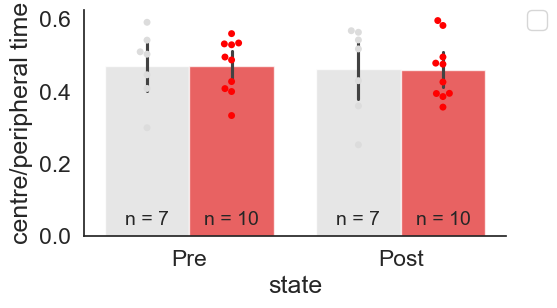

In [95]:
fig = plt.figure(figsize = (12,10))
n = [7, 7, 10, 10]
sns.set(font_scale=1.5)
sns.set_style("white")
ax1 = fig.add_subplot(321)
category_plotting_2('state','ratio','state_after',open_data_merge, ax1,['gainsboro', 'red'])
ax1.set(ylabel = 'centre/peripheral time')
autolabel_2(ax1, n)
plt.savefig('openfield.jpg', dpi = 300)

ax2 = fig.add_subplot(322)
category_plotting_2('state','In zone centre / center-point Cumulative Duration s', 
                    'state_after',open_data_merge, ax2, ['gainsboro', 'red'])
ax2.set(ylabel = 'duration in\ncentre /s')
ax2.set_xlabel('')
autolabel_2(ax2, n)

ax3 = fig.add_subplot(323)
category_plotting_2('state','In zone centre / center-point Frequency',
                    'state_after',open_data_merge, ax3, ['gainsboro', 'red'])
ax3.set(ylabel = 'frequency in\ncentre /s')
ax3.set_xlabel('')
autolabel_2(ax3, n)

ax4 = fig.add_subplot(324)
category_plotting_2('state','Velocity center-point Mean cm/s',
                    'state_after',open_data_merge, ax4,['gainsboro', 'red'])
ax4.set(ylabel = 'mean centre\npoint velocity\n/ms-1')
ax4.set_xlabel('')
autolabel_2(ax4, n)

ax5 = fig.add_subplot(325)
category_plotting_2('state','Movement Moving / center-point Cumulative Duration s',
                    'state_after',open_data_merge, ax5, ['gainsboro', 'red'])
ax5.set(ylabel = 'total time\nspent moving /s')
ax5.set_xlabel('')
autolabel_2(ax5, n)

ax6 = fig.add_subplot(326)
category_plotting_2('state','ratio','state_before',open_data_merge,ax6,['gainsboro', 'royalblue'])
fig.subplots_adjust(wspace=0.8)
ax6.set(ylabel = 'ratio of total time\nspent in centre\n vs periphery')
ax6.set_xlabel('')
autolabel_2(ax6, n)

# Baseline activity examination

baseline data extraction and merging

In [96]:
base_data = pd.read_csv('Statistics-baseline_MC+2.csv')
base_data['mice_ID'] = ID
base_data['moving ratio'] = base_data['Movement Moving / center-point Cumulative Duration'].div(
                            base_data['in Arena Arena / center-point Cumulative Duration'])
base_data_merge = pd.merge(base_data, agg_cond_data_first, how = 'left', on = 'mice_ID')

calculating stats for baseline parameters - comparing pre and post state 

In [97]:
parameters = ['Distance moved center-point Total', 'Velocity center-point Mean', 
              'moving ratio','In centre centre / center-point Cumulative Duration',
              'Distance to zone centre / center-point Mean']

for param in parameters:
    stats_base, p_base = stats.ttest_ind(base_data_merge[maze_data_merge['state_after'] == 'Agg+'][param],
                               base_data_merge[maze_data_merge['state_after'] == 'Agg-'][param],
                               equal_var = False)
    print(param, p_base)

Distance moved center-point Total 0.15241728721814812
Velocity center-point Mean 0.1495017559202885
moving ratio 0.1551939281171604
In centre centre / center-point Cumulative Duration 0.6605170186770086
Distance to zone centre / center-point Mean 0.18292826317963348


visualizing baseline parameters of Agg+ and Agg- groups

IndexError: list index out of range

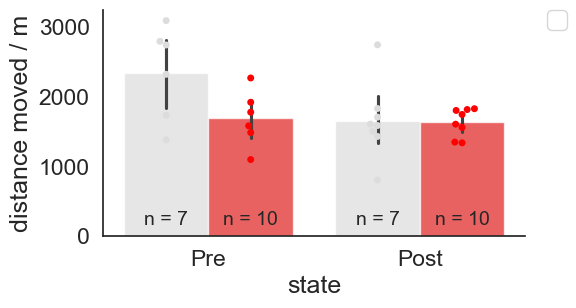

In [98]:
fig = plt.figure(figsize = (12,10))
ax1 = fig.add_subplot(321)
category_plotting_2('state','Distance moved center-point Total',
                    'state_after',base_data_merge, ax1, ['gainsboro', 'red'])
ax1.set(ylabel = 'distance moved / m')
autolabel_2(ax1, n)

ax2 = fig.add_subplot(322)
category_plotting_2('state','Velocity center-point Mean', 
                    'state_after',base_data_merge, ax2, ['gainsboro', 'red'])
ax2.set(ylabel = 'velocity / ms^-1')
autolabel_2(ax2, n)

ax3 = fig.add_subplot(323)
category_plotting_2('state','moving ratio',
                    'state_after',base_data_merge, ax3, ['gainsboro', 'red'])
ax3.set(ylabel = 'ratio of moving and\nnon-moving time')
ax3.set_xlabel('')
autolabel_2(ax3, n)

ax4 = fig.add_subplot(324)
category_plotting_2('state','In centre centre / center-point Cumulative Duration',
                    'state_after',base_data_merge, ax4, ['gainsboro', 'red'])
ax4.set(ylabel = 'in centre duration / s')
ax4.set_xlabel('')
autolabel_2(ax4, n)

ax5 = fig.add_subplot(325)
category_plotting_2('state','Distance to zone centre / center-point Mean',
                    'state_after',base_data_merge, ax5, ['gainsboro', 'red'])
ax5.set(ylabel = 'average distance\nto centre / m')
ax5.set_xlabel('')
autolabel_2(ax5, n)

fig.subplots_adjust(wspace=1.0)
plt.savefig('output_figures/baseline.jpg', dpi = 300)

# Sensitization Analysis

extact proportion of mice turning to be aggressive after different number of pup exposure

In [99]:
dep_data = data[data['exp_cond'] == 'food_deprivation'][data['target'].isin(['pup', 'intruder', 'maze', 'cricket'])]
proportion = {}
ns_time = {}

i = 0
for i in data.exp_time.unique():
    dep_time_data = dep_data[dep_data['exp_time'] == i]
    
    if i > 1:
        dep_time_data = dep_time_data.loc[dep_time_data['prev_exp'].isin(['food_deprivation(4)', 'food_deprivation(5)'])]
        
    agg_time_data = dep_time_data[dep_time_data['state_after'] == 'Agg+'] 
    proportion[str(i)] = len(agg_time_data) / len(dep_time_data)
    ns_time[str(i)] = len(dep_time_data)

print(proportion)
print(ns_time)

{'1': 0.47368421052631576, '2': 0.16666666666666666, '3': 0.045454545454545456, '4': 0.0}
{'1': 76, '2': 30, '3': 22, '4': 18}


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/2017659113.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dep_data = data[data['exp_cond'] == 'food_deprivation'][data['target'].isin(['pup', 'intruder', 'maze', 'cricket'])]


plot proportion turning to be aggressive versus times of pup exposure

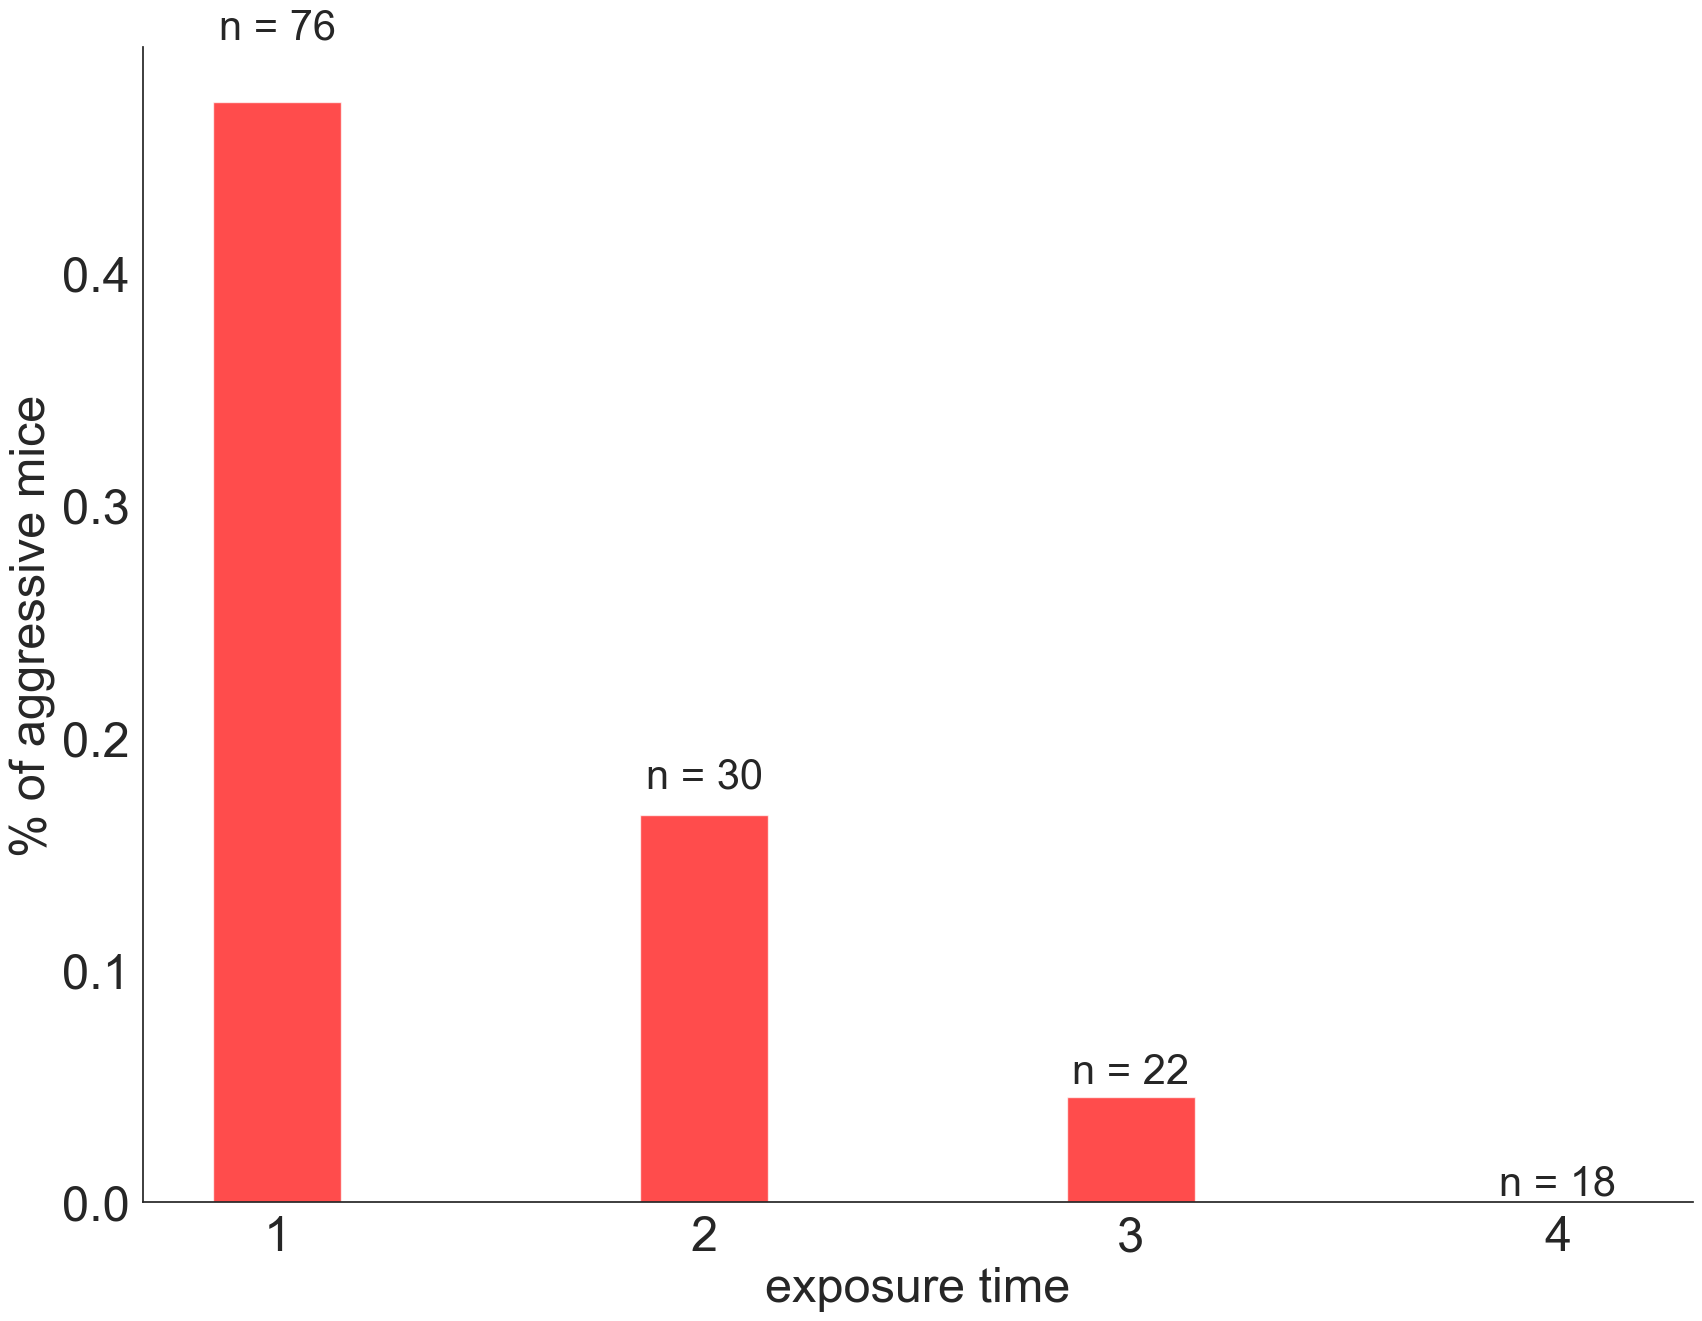

In [100]:
fig , ax = plt.subplots(figsize = (20, 15))
fig = plt.bar(range(len(proportion)), list(proportion.values()),
        tick_label = list(proportion.keys()), align = 'center', 
        color = 'red', width = 0.3, alpha = 0.7)

plt.xlabel('exposure time', fontsize = 35)
plt.ylabel('% of aggressive mice', fontsize = 35)
#plt.title('proportion of mice turning to be aggressive\n after different numbers of pup exposure',
#         fontsize = 35, **font, y = 1.08)

i = 0
for position in fig:
    plt.text(position.get_x() + position.get_width()/2., 1.05 * position.get_height(),
            'n = ' + str(list(ns_time.values())[i]) ,ha='center', va='bottom', fontsize = 30)
    i += 1

plt.xticks(fontsize = 35)
plt.yticks(fontsize = 35)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.show()

define dataset containing data of each exposure and extract food intake lines from specified mice groups

In [101]:
lines_1 = []
lines_2 = []
lines_3 = []
ids_1 = []
ids_2 = []
ids_3 = []
food_exp = pd.melt(agg_cond_data,id_vars = ['mice_ID', 'exp_time'], value_vars = ['1h_food_consumption_after']).dropna()

for id in food_exp['mice_ID'].unique():
    if len(food_exp.loc[food_exp['mice_ID'] == id]) > 1 :
        ids_1.append(id)
        lines_1.append(food_exp.loc[food_exp['mice_ID'] == id]['value'][:2].tolist())
        
    if len(food_exp.loc[food_exp['mice_ID'] == id]) > 2:
        ids_2.append(id)
        lines_2.append(food_exp.loc[food_exp['mice_ID'] == id]['value'][1:3].tolist())
        
    if len(food_exp.loc[food_exp['mice_ID'] == id]) > 3:
        ids_3.append(id)
        lines_3.append(food_exp.loc[food_exp['mice_ID'] == id]['value'][2:4].tolist())
        

visualizing individual mouse food intake across 

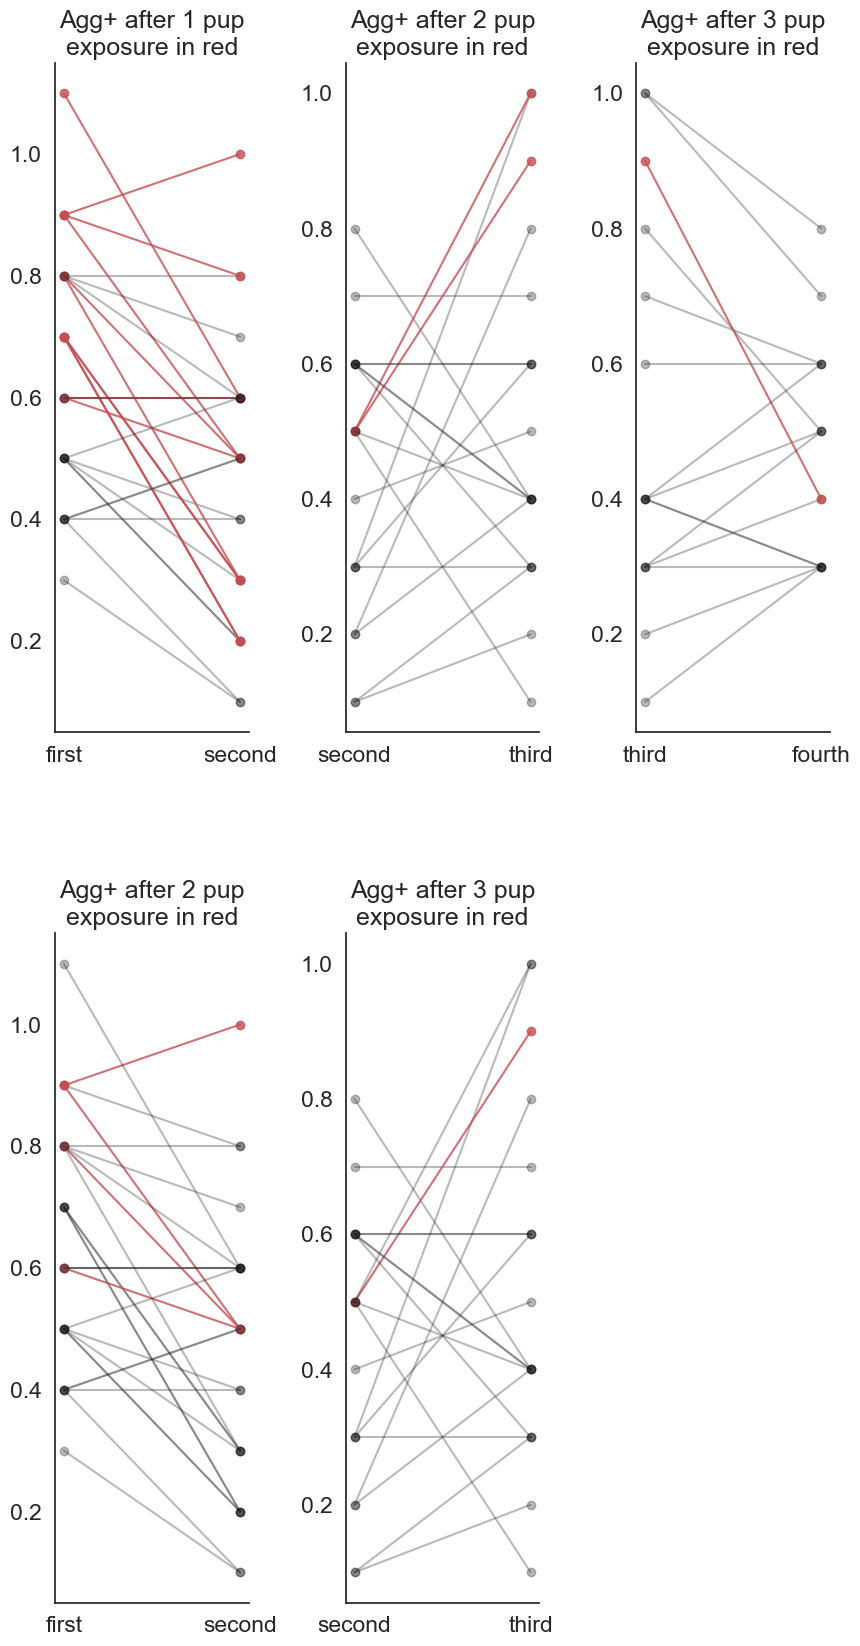

In [102]:
fig = plt.figure(figsize = (10,20))
sns.set(font_scale=1.5)
sns.set_style("white")
ax1 = fig.add_subplot(231) 
x_axis_1 = ['first', 'second']
paired_line(agg_cond_data_first, lines_1,
            'mice_ID', ids_1, 
            'state_after', 'Agg+', 
            x_axis_1)
plt.title('Agg+ after 1 pup\nexposure in red')

ax2 = fig.add_subplot(232) 
x_axis_2 = ['second', 'third']
agg_cond_data_second = agg_cond_data[agg_cond_data['exp_time'] == 2]
paired_line(agg_cond_data_second, lines_2,
            'mice_ID', ids_2, 
            'state_after', 'Agg+', 
            x_axis_2)
plt.title('Agg+ after 2 pup\nexposure in red')

ax3 = fig.add_subplot(233) 
x_axis_3 = ['third', 'fourth']
agg_cond_data_third = agg_cond_data[agg_cond_data['exp_time'] == 3]
paired_line(agg_cond_data_third, lines_3,
            'mice_ID', ids_3, 
            'state_after', 'Agg+', 
            x_axis_3)
plt.title('Agg+ after 3 pup\nexposure in red')

ax4 = fig.add_subplot(234) 

#paired_line(agg_cond_data_first, lines_1,
#            'mice_ID', ids_1, 
#            'state_after', 'Agg+', 
#            x_axis_1, colour = 'blue')
#plt.title('Agg+ when exp_time = 1')

paired_line(agg_cond_data_second, lines_1,
            'mice_ID', ids_1, 
            'state_after', 'Agg+', 
            x_axis_1)
plt.title('Agg+ after 2 pup\nexposure in red')

ax5 = fig.add_subplot(235) 
paired_line(agg_cond_data_third, lines_2,
            'mice_ID', ids_2, 
            'state_after', 'Agg+', 
            x_axis_2)
plt.title('Agg+ after 3 pup\nexposure in red')
fig.subplots_adjust(wspace=0.5, hspace = 0.3)

In [103]:
id_data = agg_cond_data_first[agg_cond_data_first['mice_ID'].isin(ids_1)].reset_index()
id_data_sec = agg_cond_data_second[agg_cond_data_second['mice_ID'].isin(ids_1)].reset_index()
id_data['intake_per_change'] = (id_data_sec['1h_food_consumption_after'] - id_data['1h_food_consumption_after']) / id_data['1h_food_consumption_after']
id_agg_first = [x for x in ids_1 if x not in ids_2]
id_agg_data_first = id_data[id_data['mice_ID'].isin(id_agg_first)]

stat_exp_fd, p_exp_fd = stats.ttest_ind(id_data[id_data['state_after'] =='Agg-']['intake_per_change'],
                                        id_data[id_data['state_after'] =='Agg+']['intake_per_change'],
                                        equal_var = False)
print(p_exp_fd)

nan


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/3519468112.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = x,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/3519468112.py:3: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x = x,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/3519468112.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x = x,
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/3519468112.py:11: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpret

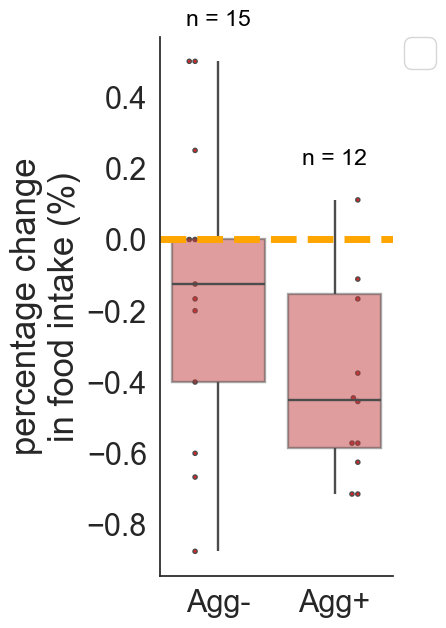

In [104]:
sns.set(rc={'figure.figsize':(3,7)})
sns.set(font_scale=2)
sns.set_style("white")
ax = category_plotting('state_after','intake_per_change', None, id_data, None)

#autolabel_2(ax, food_intake_n)
plt.axhline(0, linestyle = 'dashed', linewidth=5, color='orange')
plt.xlabel(None)
plt.ylabel('percentage change\nin food intake (%)', fontsize=25)

nobs = ["n = " + str(i) for i in (len(id_data[id_data['state_after'] =='Agg-']), 
                                  len(id_data[id_data['state_after'] =='Agg+']))]
sens_max = [id_data[id_data['state_after'] == state]['intake_per_change'].max() for state in ['Agg-', 'Agg+']]

pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],
            sens_max[tick] + 0.1,
            nobs[tick],
            horizontalalignment='center',
            size='x-small',
            color='black')

# Refeeding Experiment

import data from refeeding experiment

In [105]:
refeeding_dat = pd.read_csv('NPW_refeeding.csv')
refeeding_dat['state'] = 'competitive_assay'
ob_per = refeeding_dat.groupby(['state','object_state']).size().reset_index(name = 'n')
fd_per = refeeding_dat.groupby(['state', 'food_state']).size().reset_index(name = 'n')

ob_per['count'] = ob_per['n'].sum()
ob_per['percentage'] = ob_per['n'] / ob_per['count'] *100
ob_per = ob_per.rename(columns = {'object_state': 'refeeding_state'})
ob_per['state'] = 'object in'



fd_per['count'] = fd_per['n'].sum()
fd_per['percentage'] = fd_per['n'] / fd_per['count'] *100
fd_per = fd_per.rename(columns = {'food_state': 'refeeding_state'})
fd_per['state'] = 'food in'


refeeding_plot = pd.concat([ob_per, fd_per])
refeeding_plot = refeeding_plot[refeeding_plot['refeeding_state'] == 'Agg+']
print(refeeding_plot)

       state refeeding_state  n  count  percentage
0  object in            Agg+  8     10        80.0
0    food in            Agg+  1     10        10.0


In [118]:
object_num = refeeding_plot[refeeding_plot.state == 'object in']['n'].iloc[0]
food_num = refeeding_plot[refeeding_plot.state == 'food in']['n'].iloc[0]
total_num = 10

_, p1, _, _= stats.chi2_contingency([[total_num,0],[object_num, total_num - object_num]])
_, p2, _, _= stats.chi2_contingency([[total_num,0],[food_num, total_num - food_num]])
print(p1, p2)

print(stats.chi2_contingency([[total_num,0],[food_num, total_num - food_num]]))


0.456056540250256 0.0003234799467258457
Chi2ContingencyResult(statistic=12.929292929292929, pvalue=0.0003234799467258457, dof=1, expected_freq=array([[5.5, 4.5],
       [5.5, 4.5]]))


/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1070157360.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(x = 'state',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/1070157360.py:2: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.barplot(x = 'state',


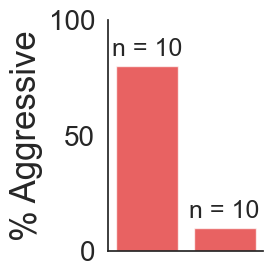

In [107]:

plt.subplots(figsize=(2, 3))
g = sns.barplot(x = 'state',
                y = 'percentage',
                data = refeeding_plot,
                alpha = 0.7, palette = ['red'])


plt.ylabel('% Aggressive', fontsize = 25)
plt.xlabel('')
plt.xticks([],[], fontsize = 20)
plt.yticks(fontsize =20)
plt.ylim(0,100)
sns.despine()

i = 0
for p in g.patches:
    g.annotate('n = '+ str(refeeding_plot['count'].tolist()[i]), (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 12), 
                textcoords='offset points', fontsize = 18)
    i = i+1

plt.savefig('output_figures/competition.pdf', dpi = 300, bbox_inches='tight')

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/104185477.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(x = 'state',
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_4043/104185477.py:5: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.barplot(x = 'state',


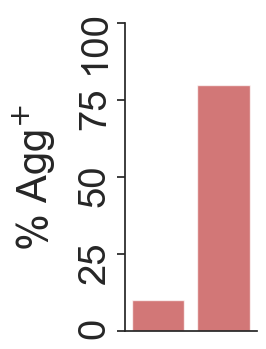

In [108]:
sns.set(rc={"figure.figsize": (1.7, 4)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(x = 'state',
                y = 'percentage',
                data = refeeding_plot, order = ['food in', 'object in'],
                alpha = 0.7, palette = ['Tab:red']
               )


plt.ylabel(r'% Agg$^{+}$', labelpad=15)
plt.xlabel('')
plt.xticks([])
plt.yticks(rotation=90)
plt.locator_params(axis='y', nbins=4)
plt.ylim(0,100)
sns.despine()

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/competition.pdf',bbox_inches='tight')

In [109]:
from lifelines import AalenJohansenFitter

food_df = refeeding_dat[refeeding_dat.state.isin(['refeeding_1h', 'competitive_assay'])]
food_df = food_df.loc[:, ['mice_ID', 'food_state', 'food_state_latency']]
object_df = refeeding_dat[refeeding_dat.state.isin(['refeeding_1h', 'competitive_assay'])]
object_df = object_df.loc[:, ['mice_ID', 'object_state', 'object_state_latency']]

food_df.loc[food_df.food_state == 'Agg-', 'food_state_latency'] = 6*60
food_df['aggression_binary'] = food_df.food_state.apply(lambda x: 1 if x == 'Agg+' else 0)
object_df.loc[object_df.object_state == 'Agg-', 'object_state_latency'] = 6*60
object_df['aggression_binary'] = object_df.object_state.apply(lambda x: 1 if x == 'Agg+' else 0)

food_df = food_df.dropna()
object_df = object_df.dropna()


/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/competitive_assay_survival.pdf'

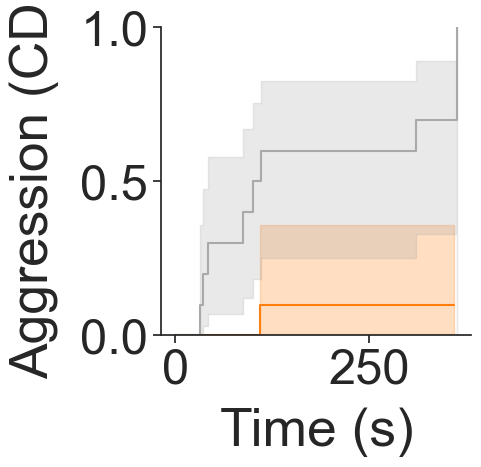

In [110]:
sns.set(rc={"figure.figsize": (4, 4)})
sns.set(font_scale=3.2) 
sns.set_style("ticks")
sns.set_palette(['Tab:orange', 'darkgray']) # vs food / vs object

ajf_food = AalenJohansenFitter(calculate_variance=True)
ajf_food.fit(food_df.food_state_latency,food_df.aggression_binary , event_of_interest=1)
ajf_food.cumulative_density_
ajf_food.plot()

ajf_object = AalenJohansenFitter(calculate_variance=True) 
ajf_object.fit(object_df.object_state_latency,object_df.aggression_binary , event_of_interest=1)
ajf_object.cumulative_density_
ajf_object.plot()

# get the legend handle of the plot
# handles, labels = plt.gca().get_legend_handles_labels()
# create a new legend from the last two handles
# plt.legend(handles[::], ['vs food', 'vs object'], bbox_to_anchor=(0.3, 1.4), loc='upper left', borderaxespad=0., fontsize = 20)
plt.legend([],[], frameon=False)
sns.despine()
plt.ylim([0,1])
plt.xlabel('Time (s)', labelpad=10)
plt.ylabel('Aggression (CD)', labelpad=15)
# plt.xticks(np.arange(0, 901, 450))
# plt.xlim(0,900)
# plt.savefig('output_figures/competitive_assay_survival.pdf', dpi=300,bbox_inches='tight')
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_1/linked_figure_S1/competitive_assay_survival.pdf',dpi = 300, bbox_inches='tight')

In [111]:
from lifelines.statistics import logrank_test
results = logrank_test(food_df.food_state_latency, object_df.object_state_latency, 
                       event_observed_A=food_df.aggression_binary, 
                       event_observed_B=object_df.aggression_binary)
results.print_summary()
print("Log-Rank Test p-value:", results.p_value)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           7.64 0.01      7.45

Log-Rank Test p-value: 0.00571692715027483
